In [128]:
# %load_ext autoreload
# %autoreload 2

import numpy as np
import pandas as pd
import os
import time
import torch
import pickle
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.ticker as ticker

from e_2_CVAE import CVAE
import e_2_CVAE_UT
from send_result import send_result, get_services
#from f_compare_bn import * 

# global var
S0 = 1.0
K = 1.0
r = 0.03
sigma = np.sqrt(0.05)
T = 1.5
BS_eta = (S0, K, r, sigma, T)
# S0, K, r, kappa, theta, xi, rho, Y0, T = Hes_eta
Hes_eta = (S0, K, r, 2, 0.05, 0.5, -0.7, 0.05, T)

B = 0.8 # down-and-out must B < S0 and B < K
model_type = 'bs' # hes, bs, bs_clip, hes_clip
# barr_type = 'barr' # van or barr
# opt_type = 'call' # call or put
# if model_type == 'bs':
#     chunk_dir = f"/mnt/d/bs_chunks_correction/" 
#     eta_path = "/mnt/d/bs_eta_basic.h5"
# elif model_type == 'bs_clip':
#     chunk_dir = f"/mnt/d/bs_clip_chunks_correction/"
#     eta_path = "/mnt/d/bs_eta_clip.h5"
# elif model_type == 'hes':
#     chunk_dir = f"/mnt/d/heston_chunks_correction/"
#     eta_path = "/mnt/d/heston_eta_basic.h5"
# elif model_type == 'hes_clip':
#     chunk_dir = f"/mnt/d/heston_clip_chunks_correction/"
#     eta_path = "/mnt/d/heston_eta_clip.h5"

if not((B < S0) & (B < K)):
    raise ValueError("down-and-out : B should be smaller than S0 and K")

# if not(opt_type == 'call' or  opt_type == 'put'):
#     raise ValueError("option_type must be 'call' or 'put'")

# if not(barr_type == 'van' or  barr_type == 'barr'):
#     raise ValueError("barr_type must be 'van' or 'barr'")

if not(model_type == 'hes' or  model_type == 'bs' or model_type == 'bs_clip' or model_type == 'hes_clip'):
    raise ValueError("model_type must be 'hes' or 'bs'")

if not(torch.cuda.is_available()):
    raise ValueError("CUDA is not available")
device = torch.device("cuda")

bs_stats = {
    "x_mean": -0.1045446063,
    "x_std": 0.6455563393,
    "m_mean": -0.4579059199,
    "m_std": 0.5553496410
}

# if model_type == 'hes':
#     if barr_type == 'barr':
#         if opt_type == 'call':
#             bench_price = 0.115733
#         else: # put
#             bench_price = 0.005170
#     else: # van
#         if opt_type == 'call':
#             bench_price = 0.124491
#         else: # put
#             bench_price = 0.080488

# elif model_type == 'bs':
#     if barr_type == 'barr':
#         if opt_type == 'call':
#             bench_price = 0.123493
#         else: # put
#             bench_price = 0.009535
#     else: # van
#         if opt_type == 'call':
#             bench_price = 0.129944
#         else: # put
#             bench_price = 0.085942

In [159]:
# base
# CVAE training settings
model_type = 'bs'
dim_z       = 2 # 2, 4, 8
hidden_dims = [256,1024,1024] # [128, 128, 64], [512, 256, 128], [1024, 512, 256], [1024, 1024, 512, 256], [1024, 1024, 1024, 1024, 1024]
batch_size  = 16384 # 1024, 2048, 128-4096, 8192, 16384, 32768, 65536
bn_chunks   = None # None or num
use_bn      = True if bn_chunks is not None else False
lr          = 2e-5 # 수렴속도 1e-4 < 1e-5
l1          = 17
lr2         = 2e-6
l2          = 18
lr3         = 1e-6
l3          = 13
beta        = 1
validation_chunk_idxs = [15,24,78]
val_every_chunks = 97
memory_on_gpu = True
warmup_chunks = None # None or num
cvae_type = "base" # "base" or "barr_weight"(exponential), "normal_weight", "add_put_loss"
weight_mode = "barrier_put" # barr_weight : "barrier_put", "barrier_near" / normal_weight, add_put_loss: "barrier_put", "all_put"
weight_alpha = 1.0
weight_alpha2 = None
weight_h = 0.01 # 0.01, 0.03, 0.04
weight_normalize = True
resume_path = None # or None 이어서 학습하고 싶을 때

num_chunks  = 1261
validate_samples = False
valid_resample = False
mt_corr = False
continuous_layer = 11
target_parameterization = "ut" # mt, ut

if cvae_type == "base":
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{l3}-{lr3}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{l3}-{lr3}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"

# over 4 layer 
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{hidden_dims[1]}_{hidden_dims[2]}_512\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{hidden_dims[1]}_{hidden_dims[2]}_512\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{continuous_layer}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{continuous_layer}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
    save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{continuous_layer}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}_resi.pt"
    result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{continuous_layer}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}_resi"
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{continuous_layer}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_{target_parameterization}_chunk{num_chunks}_resi.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{continuous_layer}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_{target_parameterization}_chunk{num_chunks}_resi"
    
elif cvae_type == "barr_weight":
    save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{weight_alpha}_{weight_h}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
    result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{weight_alpha}_{weight_h}_{validation_chunk_idxs}_chunk{num_chunks}"
    

elif cvae_type == "add_put_loss" or cvae_type == "normal_weight":
    save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{weight_mode}_{weight_alpha}_{validation_chunk_idxs}_chunk{num_chunks}_fine.pt"
    result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{weight_mode}_{weight_alpha}_{validation_chunk_idxs}_chunk{num_chunks}_fine"

if 'base' in save_path:
    raise ValueError("base는 save_path에 포함되면 안됨.")

n_samples = 10000 # n_samples= 1k, 10k, 100k
if n_samples % 2 != 0:
    raise ValueError("n_samples should be an even number for antithetic sampling")

if model_type == 'hes':
    test_etas = [0.03, 2.0,  0.05, 0.5, -0.7, 0.05, 1.5]
    eta_keys  = ['r', 'lambda', 'v_bar', 'xi', 'rho', 'Y0', 'T']
else: # model_type = 'bs'
    test_etas = [r, sigma, T]
    eta_keys  = ['r', 'sigma', 'T']

if "ut" in save_path:
    ckpt = torch.load(save_path, map_location=device, weights_only=False)
    cvae = e_2_CVAE_UT.CVAE.from_checkpoint(ckpt).to(device)
else:
    ckpt = torch.load(save_path, map_location=device, weights_only=False)
    cvae = CVAE(
        dim_x=ckpt["dim_x"],
        dim_eta=ckpt["dim_eta"],
        dim_z=ckpt["dim_z"],
        hidden_dims=ckpt["hidden_dims"],
        use_bn=ckpt.get("use_bn", False),
        residual_blocks=ckpt.get("residual_blocks", 0),
    ).to(device)
    
    state_dict = ckpt["model_state"]
    if any(k.startswith("module.") for k in state_dict):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

    cvae.load_state_dict(state_dict)

cvae.eval()

eta_raw = np.array(test_etas, dtype=np.float32)
eta_scaled = (eta_raw - ckpt["eta_min"]) / (ckpt["eta_max"] - ckpt["eta_min"] + 1e-8)
eta_t = torch.tensor(eta_scaled, dtype=torch.float32, device=device)

In [152]:
# hes
# CVAE training settings
model_type = 'hes'
dim_z       = 2 # 2, 4, 8
hidden_dims = [256,1024,1024] # [128, 128, 64], [512, 256, 128], [1024, 512, 256], [1024, 1024, 512, 256], [1024, 1024, 1024, 1024, 1024]
batch_size  = 16384 # 1024, 2048, 128-4096, 8192, 16384, 32768, 65536
bn_chunks   = None # None or num
use_bn      = True if bn_chunks is not None else False
lr          = 2e-5 # 수렴속도 1e-4 < 1e-5
l1          = 18
lr2         = 2e-6
l2          = 19
lr3         = 1e-6
l3          = 13
beta        = 1
validation_chunk_idxs = [15,24,78]
val_every_chunks = 97
memory_on_gpu = True
warmup_chunks = None # None or num
cvae_type = "base" # "base" or "barr_weight"(exponential), "normal_weight", "add_put_loss"
weight_mode = "barrier_put" # barr_weight : "barrier_put", "barrier_near" / normal_weight, add_put_loss: "barrier_put", "all_put"
weight_alpha = 0.4
weight_alpha2 = None
weight_h = 0.01 # 0.01, 0.03, 0.04
weight_normalize = True
resume_path = None # or None 이어서 학습하고 싶을 때

num_chunks  = 873
validate_samples = False
valid_resample = False
mt_corr = False # True 일때는 validate_samples = False
continuous_layer = 21
target_parameterization = "ut" # mt, ut

if cvae_type == "base":
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{l3}-{lr3}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{l3}-{lr3}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"

# over 4 layer 
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{hidden_dims[1]}_{hidden_dims[2]}_512\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{hidden_dims[1]}_{hidden_dims[2]}_512\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{continuous_layer}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{continuous_layer}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
    save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{continuous_layer}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}_resi.pt"
    result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{continuous_layer}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}_resi"
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{continuous_layer}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_{target_parameterization}_chunk{num_chunks}_resi.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{continuous_layer}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_{target_parameterization}_chunk{num_chunks}_resi"
    
elif cvae_type == "barr_weight":
    save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{weight_alpha}_{weight_h}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
    result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{weight_alpha}_{weight_h}_{validation_chunk_idxs}_chunk{num_chunks}"
    

elif cvae_type == "add_put_loss" or cvae_type == "normal_weight":
    save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{weight_mode}_{weight_alpha}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
    result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{weight_mode}_{weight_alpha}_{validation_chunk_idxs}_chunk{num_chunks}"


if 'base' in save_path:
    raise ValueError("base는 save_path에 포함되면 안됨.")

n_samples = 10000 # n_samples= 1k, 10k, 100k
if n_samples % 2 != 0:
    raise ValueError("n_samples should be an even number for antithetic sampling")

if model_type == 'hes' or model_type == 'hes_clip':
    test_etas = [0.03, 2.0,  0.05, 0.5, -0.7, 0.05, 1.5]
    eta_keys  = ['r', 'lambda', 'v_bar', 'xi', 'rho', 'Y0', 'T']
else: # model_type = 'bs'
    test_etas = [r, sigma, T]
    eta_keys  = ['r', 'sigma', 'T']

if "ut" in save_path:
    ckpt = torch.load(save_path, map_location=device, weights_only=False)
    cvae = e_2_CVAE_UT.CVAE.from_checkpoint(ckpt).to(device)
else:
    ckpt = torch.load(save_path, map_location=device, weights_only=False)
    cvae = CVAE(
        dim_x=ckpt["dim_x"],
        dim_eta=ckpt["dim_eta"],
        dim_z=ckpt["dim_z"],
        hidden_dims=ckpt["hidden_dims"],
        use_bn=ckpt.get("use_bn", False),
        residual_blocks=ckpt.get("residual_blocks", 0),
    ).to(device)
    
    state_dict = ckpt["model_state"]
    if any(k.startswith("module.") for k in state_dict):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

    cvae.load_state_dict(state_dict)

cvae.eval()

eta_raw = np.array(test_etas, dtype=np.float32)
eta_scaled = (eta_raw - ckpt["eta_min"]) / (ckpt["eta_max"] - ckpt["eta_min"] + 1e-8)
eta_t = torch.tensor(eta_scaled, dtype=torch.float32, device=device)

# barrier put 확인 및 파라미터 확인

In [60]:
import h5py
from pathlib import Path

chunk_path = Path("/mnt/d/heston_eta_basic.h5")

with h5py.File(chunk_path, "r") as h5:
    data = h5["etas"]
    etas = data[:]

    mask = ( # bs : [r, σ, T] / hes : [r, lamb, v_bar, epsilon, rho, Y0, T] = [r, 2, 0.05, 0.5, -0.7, 0.05, T]
        # np.isclose(etas[:, 0], 0.03, atol=1e-3) &
        # np.isclose(etas[:, 1], 0.05, atol=1e-3) &
        # np.isclose(etas[:, 2], 1.50, atol=1e-2)
        np.isclose(etas[:, 0], 0.03, atol=1e-2) &
        np.isclose(etas[:, 1], 2, atol=1e-1) &
        np.isclose(etas[:, 2], 0.05, atol=1e-2) &
        np.isclose(etas[:, 3], 0.5, atol=1e-1) &
        np.isclose(etas[:, 4], -0.7, atol=1e-1) &
        np.isclose(etas[:, 5], 0.05, atol=1e-2) &
        np.isclose(etas[:, 6], 1.50, atol=1e-1)
    )

    indices = np.flatnonzero(mask)

print(etas[indices[:15],:])
print("해당 데이터 개수:", len(indices))

[[ 0.02549623  2.03400138  0.04962836  0.4256956  -0.6449425   0.05149147
   1.48112828]
 [ 0.03191545  2.06399795  0.05913385  0.48183869 -0.66053508  0.04779925
   1.51381867]
 [ 0.03025348  2.02699385  0.04739828  0.42834176 -0.78350273  0.05995157
   1.50658889]
 [ 0.02030675  1.97716558  0.05240273  0.5445552  -0.61955759  0.05901095
   1.45776603]
 [ 0.0340345   2.0050081   0.04216678  0.56854305 -0.6771267   0.04098713
   1.50811093]
 [ 0.02793278  1.94699702  0.04310769  0.43985161 -0.62630174  0.049116
   1.43117924]
 [ 0.03789554  1.9590087   0.0451546   0.41345353 -0.64852788  0.04607392
   1.4993648 ]
 [ 0.0256345   1.96013074  0.04671223  0.45376873 -0.64284316  0.05804692
   1.43402117]
 [ 0.03207305  2.02620431  0.05233434  0.55652498 -0.79695562  0.04066524
   1.58527692]]
해당 데이터 개수: 9


In [62]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from itertools import repeat
from multiprocessing import get_context
from pathlib import Path

from f_robust import *

chunk_dir = Path("/mnt/d/heston_chunks_correction")
chunk_paths = [
    chunk_dir / f"heston_chunk_{i:03d}.h5"
    for i in range(100)
]

target_eta_idxs = np.asarray(indices, dtype=np.int64)
row_batch_size = 100_000
max_workers = 4

matched_rows_by_file = []
with ProcessPoolExecutor( # 6m
    max_workers=max_workers,
    mp_context=get_context("spawn"),
) as executor:
    results = executor.map(
        search_chunk_for_eta_indices,
        chunk_paths,
        repeat(target_eta_idxs),
        repeat(row_batch_size),
    )

    # executor.map은 입력 파일 순서를 유지합니다.
    for chunk_name, selected in results:
        if selected is None:
            print("파일 없음:", chunk_name)
            continue

        print(f"검색 완료: {chunk_name} | 발견={len(selected):,}")
        if len(selected) > 0:
            matched_rows_by_file.append((chunk_name, selected))

if matched_rows_by_file:
    matched_rows = np.concatenate(
        [selected for _, selected in matched_rows_by_file],
        axis=0,
    )
    matched_files = np.concatenate([
        np.full(len(selected), chunk_name, dtype=object)
        for chunk_name, selected in matched_rows_by_file
    ])
    print("총 발견 개수:", len(matched_rows))
else:
    matched_rows = np.empty((0, 3), dtype=np.float64)
    matched_files = np.array([], dtype=object)
    print("해당 eta index를 찾지 못했습니다.")

검색 완료: heston_chunk_000.h5 | 발견=0
검색 완료: heston_chunk_001.h5 | 발견=0
검색 완료: heston_chunk_002.h5 | 발견=0
검색 완료: heston_chunk_003.h5 | 발견=0
검색 완료: heston_chunk_004.h5 | 발견=0
검색 완료: heston_chunk_005.h5 | 발견=0
검색 완료: heston_chunk_006.h5 | 발견=0
검색 완료: heston_chunk_007.h5 | 발견=0
검색 완료: heston_chunk_008.h5 | 발견=0
검색 완료: heston_chunk_009.h5 | 발견=0
검색 완료: heston_chunk_010.h5 | 발견=0
검색 완료: heston_chunk_011.h5 | 발견=1,024
검색 완료: heston_chunk_012.h5 | 발견=0
검색 완료: heston_chunk_013.h5 | 발견=0
검색 완료: heston_chunk_014.h5 | 발견=0
검색 완료: heston_chunk_015.h5 | 발견=1,024
검색 완료: heston_chunk_016.h5 | 발견=0
검색 완료: heston_chunk_017.h5 | 발견=0
검색 완료: heston_chunk_018.h5 | 발견=0
검색 완료: heston_chunk_019.h5 | 발견=0
검색 완료: heston_chunk_020.h5 | 발견=0
검색 완료: heston_chunk_021.h5 | 발견=0
검색 완료: heston_chunk_022.h5 | 발견=0
검색 완료: heston_chunk_023.h5 | 발견=0
검색 완료: heston_chunk_024.h5 | 발견=0
검색 완료: heston_chunk_025.h5 | 발견=0
검색 완료: heston_chunk_026.h5 | 발견=0
검색 완료: heston_chunk_027.h5 | 발견=0
검색 완료: heston_chunk_028.h5 | 발견=0
검색 완료:

In [63]:
import numpy as np

K = 1.0
B = 0.8
r = 0.03
T = 1.5

for eta_idx in target_eta_idxs:
    mask = matched_rows[:, 0].astype(np.int64) == eta_idx
    rows = matched_rows[mask]

    if len(rows) == 0:
        print(f"eta_index={eta_idx}: 데이터 없음")
        continue

    X_T = rows[:, 1]
    M_T = rows[:, 2]

    S_T = np.exp(X_T)
    alive = M_T > np.log(B)  # down-and-out barrier 생존 여부
    payoff = np.maximum(K - S_T, 0.0) * alive

    discounted_payoff = np.exp(-r * T) * payoff
    price = discounted_payoff.mean()
    std_error = discounted_payoff.std(ddof=1) / np.sqrt(len(rows))
    ci95 = 1.96 * std_error

    print(f"\neta_index={eta_idx}")
    print(f"n paths       : {len(rows):,}")
    print(f"alive ratio   : {alive.mean():.6f}")
    print(f"Barrier Put   : {price:.8f}")
    print(f"95% CI        : [{price-ci95:.8f}, {price+ci95:.8f}]")


eta_index=752503
n paths       : 1,024
alive ratio   : 0.619141
Barrier Put   : 0.00811156
95% CI        : [0.00637729, 0.00984582]

eta_index=1036011
n paths       : 1,024
alive ratio   : 0.573242
Barrier Put   : 0.00527034
95% CI        : [0.00395621, 0.00658446]

eta_index=2423114
n paths       : 1,024
alive ratio   : 0.589844
Barrier Put   : 0.00556067
95% CI        : [0.00413168, 0.00698965]

eta_index=3571287
n paths       : 1,024
alive ratio   : 0.589844
Barrier Put   : 0.00476688
95% CI        : [0.00346418, 0.00606958]

eta_index=4234508
n paths       : 1,024
alive ratio   : 0.667969
Barrier Put   : 0.00591061
95% CI        : [0.00452524, 0.00729598]

eta_index=4247254
n paths       : 1,024
alive ratio   : 0.648438
Barrier Put   : 0.00625988
95% CI        : [0.00480640, 0.00771336]

eta_index=4876066
n paths       : 1,024
alive ratio   : 0.629883
Barrier Put   : 0.00575074
95% CI        : [0.00443267, 0.00706880]

eta_index=5905995
n paths       : 1,024
alive ratio   : 0.6162

# Loss history

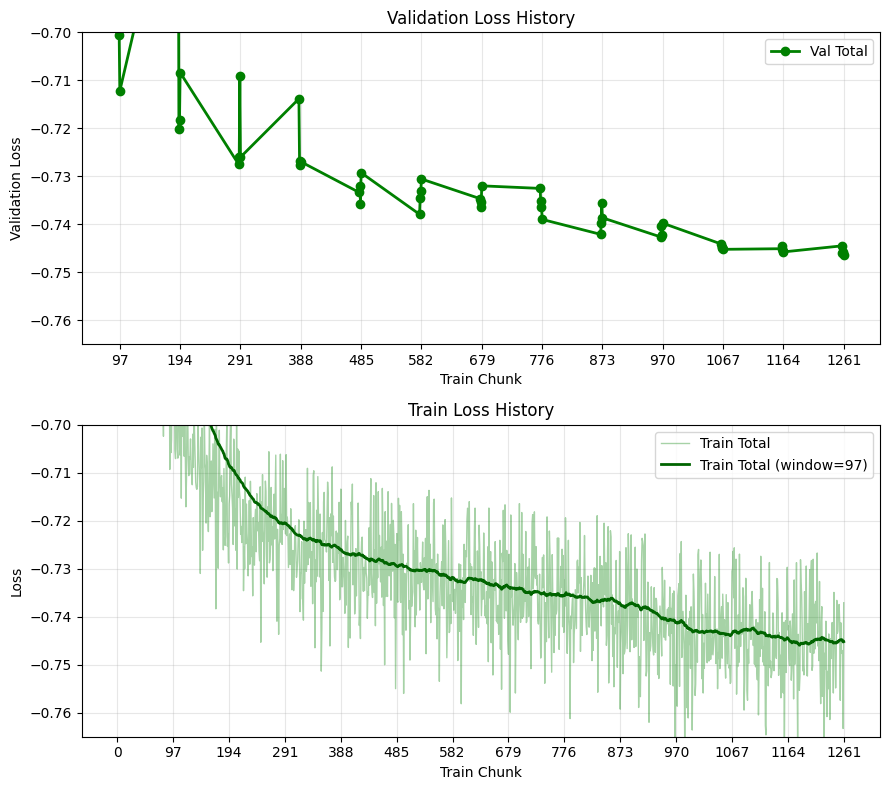

In [164]:
window = 97
if model_type == 'hes_clip':
    epoch = 194
else:
    epoch = 97

chunk_loss_history = ckpt.get("chunk_loss_history", None)

if chunk_loss_history is None:
    raise ValueError("checkpoint에 chunk_loss_history가 없습니다.")

train_chunks = np.arange(1, len(chunk_loss_history["total_loss"]) + 1)
val_chunks = np.asarray(chunk_loss_history.get("val_global_chunk", []), dtype=int)
has_val = len(val_chunks) > 0

n_rows = 2 if has_val else 1
fig, axes = plt.subplots(n_rows, 1, figsize=(9, 4 * n_rows), sharex=False)
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

#train loss history
# ax = axes[2]
# ax.plot(train_chunks, chunk_loss_history["total_loss"], label="Train Total", color="green", linewidth=2)
# ax.plot(train_chunks, chunk_loss_history["recon_loss"], label="Train Recon", color="blue", linestyle="--", linewidth=2)
# ax.plot(train_chunks, chunk_loss_history["KL_loss"], label="Train KL", color="orange", linewidth=2)
# ax.set_xlabel("Train Chunk")
# ax.set_ylabel("Loss")
# ax.set_title("Train Loss History")
# ax.xaxis.set_major_locator(ticker.MultipleLocator(97))
# ax.legend()
# ax.grid(True, alpha=0.3)

# validation loss history
if has_val:
    ax = axes[0]
    ax.plot(val_chunks, chunk_loss_history["val_total_loss"], marker="o", label="Val Total", color="green", linewidth=2)
    #ax.plot(val_chunks, chunk_loss_history["val_recon_loss"], marker="o", label="Val Recon", color="blue", linestyle="--", linewidth=2)
    #ax.plot(val_chunks, chunk_loss_history["val_KL_loss"], marker="o", label="Val KL", color="orange", linewidth=2)
    ax.set_xlabel("Train Chunk")
    ax.set_ylabel("Validation Loss")
    if cvae_type == "add_put_loss":
        ax.set_ylim(-8.7, -8.5)
    elif model_type =='bs' or model_type == 'bs_clip':
        ax.set_ylim(-0.765, -0.70)
        if cvae_type == "barr_weight" and weight_mode == "barrier_put":
            ax.set_ylim(-1.125, -1.0)
        if cvae_type == "normal_weight" and weight_mode == "barrier_put":
            if weight_alpha == 1.0:
                ax.set_ylim(-1.03, -0.95)
            elif weight_alpha == 0.7:
                ax.set_ylim(-0.93, -0.86)
            elif weight_alpha == 0.6 or weight_alpha == 0.55:
                ax.set_ylim(-0.89, -0.84)
            elif weight_alpha == 0.5 or weight_alpha == 0.45:
                ax.set_ylim(-0.87, -0.80)
            elif weight_alpha == 0.4:
                ax.set_ylim(-0.85, -0.78)
            elif weight_alpha == 0.3:
                ax.set_ylim(-0.83, -0.76)
            elif weight_alpha == 0.2:
                ax.set_ylim(-0.82, -0.74)
            elif weight_alpha == 0.1:
                ax.set_ylim(-0.80, -0.70)
        if cvae_type == "normal_weight" and weight_mode == "all_put":
            if weight_alpha == 0.4:
                ax.set_ylim(-1.03, -0.80)
            elif weight_alpha == 0.2:
                ax.set_ylim(-0.89, -0.81)
            elif weight_alpha == 0.6:
                ax.set_ylim(-1.20, -1.06)
            elif weight_alpha == 0.8:
                ax.set_ylim(-1.30, -1.2)

        if weight_alpha2 == 0.2:
            ax.set_ylim(-0.92, -0.84)
        elif weight_alpha2 == 0.3:
            ax.set_ylim(-1.02, -0.91)

        if "ut" in save_path:
            ax.set_ylim(1.65, 1.9)
    elif model_type == 'hes':
        ax.set_ylim(-1.30, -1.26)
        if cvae_type == "normal_weight" and weight_mode == "barrier_put":
            if weight_alpha == 0.6 or weight_alpha == 0.55:
                ax.set_ylim(-1.45, -1.42)
            elif weight_alpha == 0.5 or weight_alpha == 0.45:
                ax.set_ylim(-1.43, -1.38)
            elif weight_alpha == 0.4:
                ax.set_ylim(-1.39, -1.36)
            elif weight_alpha == 0.3:
                ax.set_ylim(-1.36, -1.34)

        if "ut" in save_path:
                ax.set_ylim(1.65, 1.9)
    elif model_type == 'hes_clip':
        ax.set_ylim(-1.615, -1.59)
    ax.set_title("Validation Loss History")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(epoch))
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    print("validation loss history가 없습니다. validation_chunk_idxs를 넣고 학습한 checkpoint인지 확인하세요.")

train_total_loss = np.asarray(chunk_loss_history["total_loss"], dtype=float)

ax = axes[1]
ax.plot(train_chunks, train_total_loss, label="Train Total", color="green", linewidth=1, alpha=0.35)
if len(train_total_loss) >= window:
    moving_average = np.convolve(train_total_loss, np.ones(window) / window, mode="valid")
    moving_average_chunks = train_chunks[window - 1:]
    ax.plot(
        moving_average_chunks, moving_average,
        label=f"Train Total (window={window})", color="darkgreen", linewidth=2,
    )
ax.set_xlabel("Train Chunk")
ax.set_ylabel("Loss")
if cvae_type == "add_put_loss":
    ax.set_ylim(-8.7, -8.5)
elif model_type =='bs' or model_type == 'bs_clip':
    ax.set_ylim(-0.765, -0.70)
    if cvae_type == "barr_weight" and weight_mode == "barrier_put":
        ax.set_ylim(-1.125, -1.0)
    if cvae_type == "normal_weight" and weight_mode == "barrier_put":
        if weight_alpha == 1.0:
            ax.set_ylim(-1.03, -0.95)
        elif weight_alpha == 0.7:
            ax.set_ylim(-0.93, -0.86)
        elif weight_alpha == 0.6 or weight_alpha == 0.55:
            ax.set_ylim(-0.89, -0.84)
        elif weight_alpha == 0.5 or weight_alpha == 0.45:
            ax.set_ylim(-0.87, -0.80)
        elif weight_alpha == 0.4:
            ax.set_ylim(-0.85, -0.78)
        elif weight_alpha == 0.3:
            ax.set_ylim(-0.83, -0.76)
        elif weight_alpha == 0.2:
            ax.set_ylim(-0.82, -0.74)
        elif weight_alpha == 0.1:
            ax.set_ylim(-0.80, -0.70)
    if cvae_type == "normal_weight" and weight_mode == "all_put":
        if weight_alpha == 0.4:
            ax.set_ylim(-1.03, -0.80)
        elif weight_alpha == 0.2:
            ax.set_ylim(-0.89, -0.81)
        elif weight_alpha == 0.6:
            ax.set_ylim(-1.20, -1.06)
        elif weight_alpha == 0.8:
            ax.set_ylim(-1.30, -1.2)

    if weight_alpha2 == 0.2:
        ax.set_ylim(-0.92, -0.84)
    elif weight_alpha2 == 0.3:
        ax.set_ylim(-1.02, -0.91)

    if "ut" in save_path:
        ax.set_ylim(1.65, 1.9)
elif model_type == 'hes':
    ax.set_ylim(-1.30, -1.26)
    if cvae_type == "normal_weight" and weight_mode == "barrier_put":
        if weight_alpha == 0.6 or weight_alpha == 0.55:
            ax.set_ylim(-1.45, -1.42)
        elif weight_alpha == 0.5 or weight_alpha == 0.45:
            ax.set_ylim(-1.43, -1.38)
        elif weight_alpha == 0.4:
            ax.set_ylim(-1.39, -1.36)
        elif weight_alpha == 0.3:
            ax.set_ylim(-1.36, -1.34)

    if "ut" in save_path:
        ax.set_ylim(1.65, 1.9)
elif model_type == 'hes_clip':
    ax.set_ylim(-1.615, -1.59)
ax.set_title("Train Loss History")
ax.xaxis.set_major_locator(ticker.MultipleLocator(epoch))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
# loss history
ckpt = torch.load(save_path, map_location=device, weights_only=False)
chunk_loss_history = ckpt.get("chunk_loss_history", None)
chunk_indices = ckpt["chunk_loss_history"]["chunk_idx"]

for i in range(len(chunk_loss_history["total_loss"])):
    print(f"Num : {chunk_loss_history['global_chunk'][i]}, Idx : {chunk_indices[i]}, Total Loss: {chunk_loss_history['total_loss'][i]:.4f}, Recon Loss: {chunk_loss_history['recon_loss'][i]:.4f}, KL Loss: {chunk_loss_history['KL_loss'][i]:.4f}")

Num : 0, Idx : 88, Total Loss: -0.4681, Recon Loss: -3.7710, KL Loss: 3.3029
Num : 1, Idx : 8, Total Loss: -0.6216, Recon Loss: -4.1774, KL Loss: 3.5558
Num : 2, Idx : 75, Total Loss: -0.6443, Recon Loss: -4.2178, KL Loss: 3.5735
Num : 3, Idx : 41, Total Loss: -0.6579, Recon Loss: -4.2663, KL Loss: 3.6084
Num : 4, Idx : 17, Total Loss: -0.6692, Recon Loss: -4.3095, KL Loss: 3.6402
Num : 5, Idx : 66, Total Loss: -0.7017, Recon Loss: -4.3882, KL Loss: 3.6865
Num : 6, Idx : 57, Total Loss: -0.6795, Recon Loss: -4.3846, KL Loss: 3.7051
Num : 7, Idx : 31, Total Loss: -0.6716, Recon Loss: -4.4189, KL Loss: 3.7473
Num : 8, Idx : 58, Total Loss: -0.6892, Recon Loss: -4.4331, KL Loss: 3.7439
Num : 9, Idx : 87, Total Loss: -0.6926, Recon Loss: -4.4574, KL Loss: 3.7648
Num : 10, Idx : 45, Total Loss: -0.6983, Recon Loss: -4.4815, KL Loss: 3.7833
Num : 11, Idx : 65, Total Loss: -0.6950, Recon Loss: -4.4997, KL Loss: 3.8048
Num : 12, Idx : 97, Total Loss: -0.6906, Recon Loss: -4.5165, KL Loss: 3.82

In [12]:
# validation dim-z KL mean value
chunk_loss_history = ckpt.get("chunk_loss_history", None)

if chunk_loss_history is None:
    raise ValueError("checkpoint에 chunk_loss_history가 없습니다.")

val_chunks = chunk_loss_history.get("val_global_chunk", [])
val_kl_dim_mean = chunk_loss_history.get("val_kl_dim_mean", [])

if len(val_chunks) == 0 or len(val_kl_dim_mean) == 0:
    raise ValueError("validation KL dim 기록이 없습니다. validation_chunk_idxs를 넣고 학습한 checkpoint인지 확인하세요.")

for i in range(len(val_chunks)):
    kl_by_dim = val_kl_dim_mean[i]
    kl_text = " | ".join([f"z{j}: {v:.6f}" for j, v in enumerate(kl_by_dim)])
    print(f"Num : {val_chunks[i]}, {kl_text}")


Num : 94, z0: 2.344837 | z1: 1.039962
Num : 95, z0: 2.339479 | z1: 1.042162
Num : 96, z0: 2.361383 | z1: 1.059373
Num : 97, z0: 2.369938 | z1: 1.066483


# inference result

In [161]:
option_keys = ["van_call", "van_put", "barr_call", "barr_put"]
n_list = [1000, 10000, 100000]
n_repeats = 50
results_by_option = {key: {n: [] for n in n_list} for key in option_keys}
sampling_diagnostics = {
    n: {
        "used_sample_count": [],
        "discarded_sample_count": [],
        "discarded_sample_pct": [],
        "regenerated_sample_count": [],
        "regenerated_sample_pct": [],
        "mt_corrected_sample_count": [],
        "mt_corrected_sample_pct": [],
    }
    for n in n_list
}

# 결과 출력용
for n in n_list:
    for _ in range(n_repeats):
        prices = cvae.total_pricing(
            eta_t, B, K, r, T, n,
            validate_samples=validate_samples,
            valid_resample=valid_resample,
            mt_corr=mt_corr,
        )
        for key in option_keys:
            results_by_option[key][n].append(prices[key])
        for key in sampling_diagnostics[n]:
            value = prices.get(key)
            if value is not None:
                sampling_diagnostics[n][key].append(value)

    used_mean = np.mean(sampling_diagnostics[n]["used_sample_count"])
    regenerated_count_mean = np.mean(
        sampling_diagnostics[n]["regenerated_sample_count"]
    )
    regenerated_pct_mean = np.mean(
        sampling_diagnostics[n]["regenerated_sample_pct"]
    )
    corrected_count_mean = np.mean(
        sampling_diagnostics[n]["mt_corrected_sample_count"]
    )
    corrected_pct_mean = np.mean(
        sampling_diagnostics[n]["mt_corrected_sample_pct"]
    )
    if validate_samples:
        discarded_count_mean = np.mean(
            sampling_diagnostics[n]["discarded_sample_count"]
        )
        discarded_pct_mean = np.mean(
            sampling_diagnostics[n]["discarded_sample_pct"]
        )
        validation_text = (
            f"discarded={discarded_count_mean:,.1f} "
            f"({discarded_pct_mean:.4f}%) "
            f"| regenerated={regenerated_count_mean:,.1f} "
            f"({regenerated_pct_mean:.4f}%)"
        )
    else:
        validation_text = "discarded=not checked | regenerated=0.0 (0.0000%)"
    print(
        f"[barrier samples] n={n:,} | validation={validate_samples} "
        f"| resample={valid_resample} | mt_corr={mt_corr} "
        f"| used={used_mean:,.1f} | {validation_text} "
        f"| mt_corrected={corrected_count_mean:,.1f} "
        f"({corrected_pct_mean:.4f}%)"
    )

for key in option_keys:
    cvae_result_path = f"{result_base_path}_{key}.pkl"
    with open(cvae_result_path, "wb") as f:
        pickle.dump(results_by_option[key], f)
    print(f"saved: {cvae_result_path}")

# 시간 측정용
# for n in n_list:
#     call_time = {n: [] for n in n_list}
#     put_time = {n: [] for n in n_list}
#     for _ in range(n_repeats):
#         torch.cuda.synchronize()
#         start = time.perf_counter()
#         prices = cvae.price_vanilla(eta_t, K, r, T, "call", n)
#         torch.cuda.synchronize()
#         call_time[n].append(time.perf_counter()-start)

#     for _ in range(n_repeats):
#         torch.cuda.synchronize()
#         start = time.perf_counter()
#         prices = cvae.price_vanilla(eta_t, K, r, T, "put", n)
#         torch.cuda.synchronize()
#         put_time[n].append(time.perf_counter()-start)
    
#     print(f"van call {n} mean time : {np.mean(call_time[n]):.6f}")
#     print(f"van put {n} mean time : {np.mean(put_time[n]):.6f}")


# for n in n_list:
#     call_time = {n: [] for n in n_list}
#     put_time = {n: [] for n in n_list}
#     for _ in range(n_repeats):
#         torch.cuda.synchronize()
#         start = time.perf_counter()
#         prices = cvae.price_barrier(eta_t, B, K, r, T, "call", n)
#         torch.cuda.synchronize()
#         call_time[n].append(time.perf_counter()-start)

#     for _ in range(n_repeats):
#         torch.cuda.synchronize()
#         start = time.perf_counter()
#         prices = cvae.price_barrier(eta_t, B, K, r, T, "put", n)
#         torch.cuda.synchronize()
#         put_time[n].append(time.perf_counter()-start)
    
#     print(f"barr call {n} mean time : {np.mean(call_time[n]):.6f}")
#     print(f"barr put {n} mean time : {np.mean(put_time[n]):.6f}")

[barrier samples] n=1,000 | validation=False | resample=False | mt_corr=False | used=1,000.0 | discarded=not checked | regenerated=0.0 (0.0000%) | mt_corrected=0.0 (0.0000%)
[barrier samples] n=10,000 | validation=False | resample=False | mt_corr=False | used=10,000.0 | discarded=not checked | regenerated=0.0 (0.0000%) | mt_corrected=0.0 (0.0000%)
[barrier samples] n=100,000 | validation=False | resample=False | mt_corr=False | used=100,000.0 | discarded=not checked | regenerated=0.0 (0.0000%) | mt_corrected=0.0 (0.0000%)
saved: result/cvae/bs/cvae_bs_2_256_11_16384_None_2e-05_1_[15, 24, 78]_chunk1261_resi_van_call.pkl
saved: result/cvae/bs/cvae_bs_2_256_11_16384_None_2e-05_1_[15, 24, 78]_chunk1261_resi_van_put.pkl
saved: result/cvae/bs/cvae_bs_2_256_11_16384_None_2e-05_1_[15, 24, 78]_chunk1261_resi_barr_call.pkl
saved: result/cvae/bs/cvae_bs_2_256_11_16384_None_2e-05_1_[15, 24, 78]_chunk1261_resi_barr_put.pkl


Vanilla Call
n=  1000 | mean=0.12966903 | std =0.00619185 |95% CI=±0.01213603 | error=-0.21%
n= 10000 | mean=0.13027095 | std =0.00179779 |95% CI=±0.00352367 | error=+0.25%
n=100000 | mean=0.13040266 | std =0.00073446 |95% CI=±0.00143954 | error=+0.35%

Vanilla Put
n=  1000 | mean=0.08518232 | std =0.00337384 |95% CI=±0.00661273 | error=-0.88%
n= 10000 | mean=0.08534679 | std =0.00119738 |95% CI=±0.00234686 | error=-0.69%
n=100000 | mean=0.08524541 | std =0.00038961 |95% CI=±0.00076364 | error=-0.81%

Barrier Call
n=  1000 | mean=0.12353321 | std =0.00598013 |95% CI=±0.01172105 | error=+0.03%
n= 10000 | mean=0.12405184 | std =0.00181877 |95% CI=±0.00356479 | error=+0.45%
n=100000 | mean=0.12422269 | std =0.00072134 |95% CI=±0.00141383 | error=+0.59%

Barrier Put
n=  1000 | mean=0.01012217 | std =0.00110537 |95% CI=±0.00216653 | error=+6.16%
n= 10000 | mean=0.00995537 | std =0.00026225 |95% CI=±0.00051402 | error=+4.41%
n=100000 | mean=0.00999465 | std =0.00010227 |95% CI=±0.00020045 | 

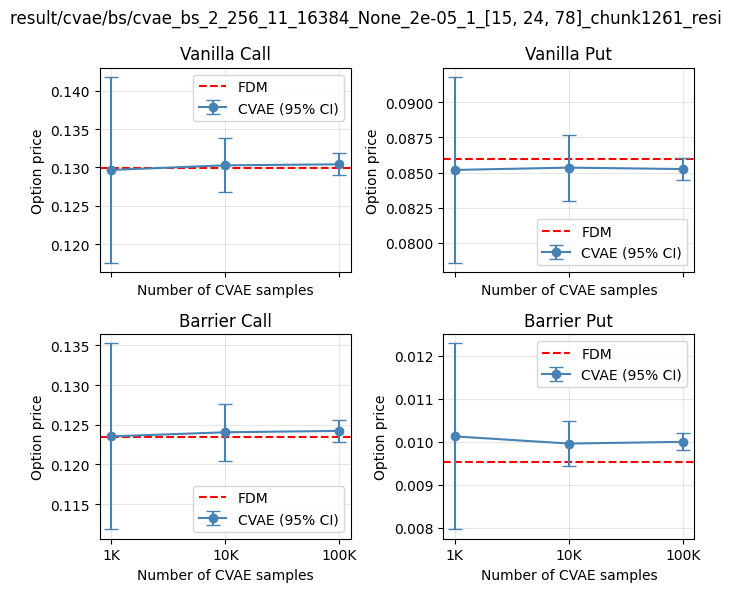

In [162]:
# CVAE inference result graphs for four option payoffs
n_list = [1000, 10000, 100000]
option_keys = ["van_call", "van_put", "barr_call", "barr_put"]
option_labels = {
    "van_call": "Vanilla Call",
    "van_put": "Vanilla Put",
    "barr_call": "Barrier Call",
    "barr_put": "Barrier Put",
}
bench_prices = {
    "hes": {
        "van_call": 0.124491,
        "van_put": 0.080488,
        "barr_call": 0.115733,
        "barr_put": 0.005170,
    },
    "bs": {
        "van_call": 0.129944,
        "van_put": 0.085942,
        "barr_call": 0.123493,
        "barr_put": 0.009535,
    },
    "hes_clip": {
        "van_call": 0.124491,
        "van_put": 0.080488,
        "barr_call": 0.115733,
        "barr_put": 0.005170,
    },
    "bs_clip": {
        "van_call": 0.129944,
        "van_put": 0.085942,
        "barr_call": 0.123493,
        "barr_put": 0.009535,
    },
}
# result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"

fig, axes = plt.subplots(2, 2, figsize=(7, 6), sharex=True)
axes = axes.ravel()

for ax, key in zip(axes, option_keys):
    with open(f"{result_base_path}_{key}.pkl", "rb") as f:
        results = pickle.load(f)

    means = np.array([np.mean(results[n]) for n in n_list])
    stds = np.array([np.std(results[n]) for n in n_list])
    ci = 1.96 * stds
    bench = bench_prices[model_type][key]

    print(option_labels[key])
    for n, mean, std, err in zip(n_list, means, stds, ci):
        rel_err = (mean - bench) / (bench) * 100
        print(f"n={n:6d} | mean={mean:.8f} | std ={std:.8f} |95% CI=±{err:.8f} | error={rel_err:+.2f}%")
    print()

    ax.axhline(bench, color="red", linestyle='--', linewidth=1.5, label="FDM")
    ax.errorbar(
        range(len(n_list)), means,
        yerr=ci, fmt="o-", color="steelblue", capsize=5, label="CVAE (95% CI)",
    )
    ax.set_xticks(range(len(n_list)))
    ax.set_xticklabels(["1K", "10K", "100K"])
    ax.set_title(option_labels[key])
    ax.set_xlabel("Number of CVAE samples")
    ax.set_ylabel("Option price")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(result_base_path)
plt.tight_layout()
plt.show()

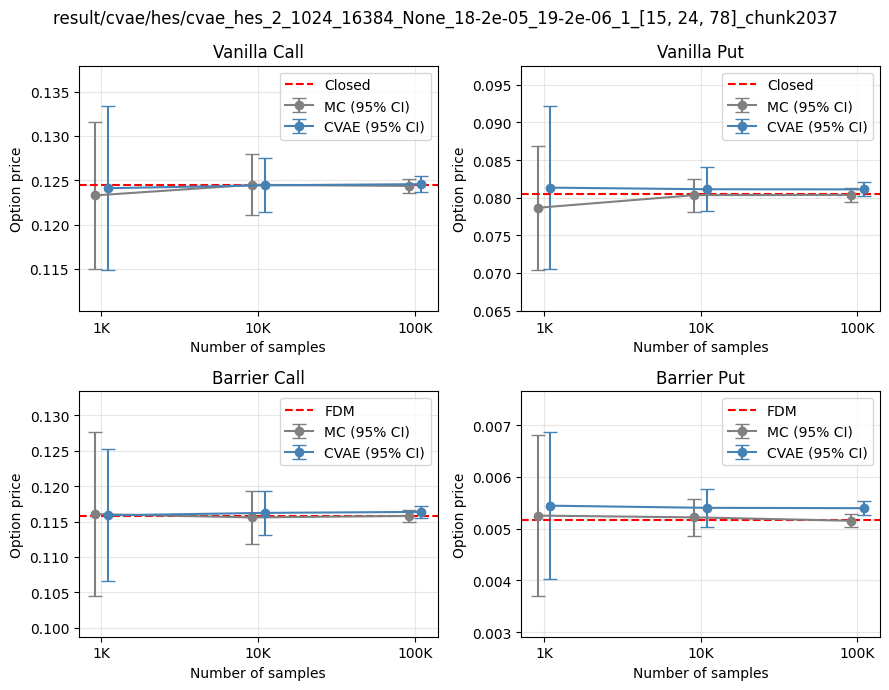

In [12]:
# 공용 그래프
n_list    = [1000, 10000, 100000]
option_keys = ["van_call", "van_put", "barr_call", "barr_put"]
option_labels = {
    "van_call": "Vanilla Call",
    "van_put": "Vanilla Put",
    "barr_call": "Barrier Call",
    "barr_put": "Barrier Put",
}
bench_prices = {
    "hes": {
        "van_call": 0.124491,
        "van_put": 0.080488,
        "barr_call": 0.115733,
        "barr_put": 0.005170,
    },
    "bs": {
        "van_call": 0.129944,
        "van_put": 0.085942,
        "barr_call": 0.123493,
        "barr_put": 0.009535,
    },
    "bs_clip": {
        "van_call": 0.129944,
        "van_put": 0.085942,
        "barr_call": 0.123493,
        "barr_put": 0.009535,
    },
}

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True)
axes = axes.ravel()

y_axis_pad_ratio = 0.25
x_axis_offset = 0.04
x_positions = np.arange(len(n_list))

for ax, key in zip(axes, option_keys):
    with open(f"{result_base_path}_{key}.pkl", "rb") as f:
        cvae_results = pickle.load(f)
    with open(f'result/mc/mc_{model_type}_{key}_results.pkl', 'rb') as f:
        mc_results = pickle.load(f)

    cvae_means = np.array([np.mean(cvae_results[n]) for n in n_list])
    cvae_stds = np.array([np.std(cvae_results[n]) for n in n_list])
    mc_means = np.array([np.mean(mc_results[n]) for n in n_list])
    mc_stds = np.array([np.std(mc_results[n]) for n in n_list])
    cvae_ci = 1.96 * cvae_stds
    mc_ci = 1.96 * mc_stds

    bench = bench_prices[model_type][key]

    y_values = np.concatenate([
        mc_means - mc_ci,
        mc_means + mc_ci,
        cvae_means - cvae_ci,
        cvae_means + cvae_ci,
    ])
    y_min = float(np.nanmin(y_values))
    y_max = float(np.nanmax(y_values))
    y_pad = (y_max - y_min) * y_axis_pad_ratio

    ax.errorbar(
        x_positions - x_axis_offset, mc_means, yerr=mc_ci,
        fmt='o-', color='grey', capsize=5, label=f'MC (95% CI)'
    )
    ax.errorbar(
        x_positions + x_axis_offset, cvae_means, yerr=cvae_ci, 
        fmt="o-", color="steelblue", capsize=5, label="CVAE (95% CI)",
    )

    bench_label = "Closed" if key.startswith("van") else "FDM"
    ax.axhline(bench, color="r", linestyle='--', linewidth=1.5, label=bench_label)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(["1K", "10K", "100K"])
    ax.tick_params(axis="x", labelbottom=True)
    ax.set_title(option_labels[key])
    ax.set_xlabel("Number of samples")
    ax.set_ylabel("Option price")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(result_base_path)
plt.tight_layout()
plt.show()


# MC, CVAE output distribution

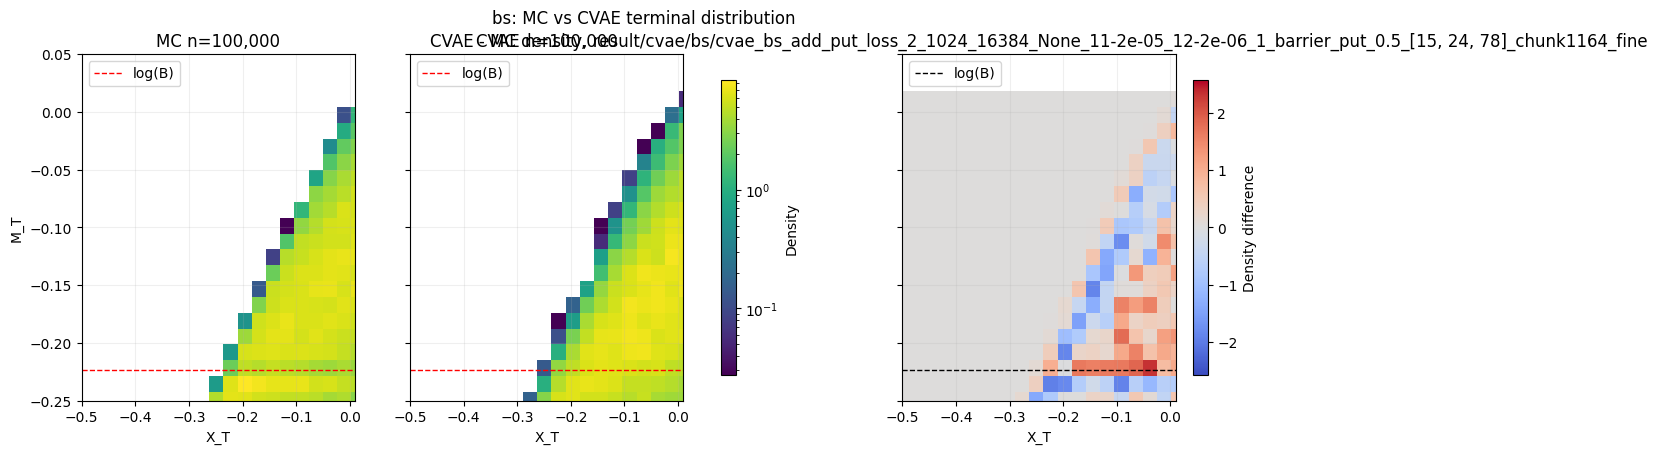

In [183]:
# MC vs CVAE (X_T, M_T) 2D distribution comparison, no pricing
from matplotlib.colors import LogNorm
from e_0_generate import gen_bs_paths, gen_heston_paths

compare_n_samples = 100000
compare_dt = 0.001
plot_bins = 100

with torch.no_grad():
    cvae_samples = cvae.sample(eta_t, compare_n_samples).cpu().numpy()
    if cvae_samples.shape[1] < 2:
        raise ValueError("CVAE sample output must contain both X_T and M_T.")
cvae_xt = cvae_samples[:, 0].astype(np.float64)
cvae_mt = cvae_samples[:, 1].astype(np.float64)

if model_type in ("bs", "bs_clip"):
    mc_xt, mc_mt, mc_mask = gen_bs_paths(
        eta_raw, S0=S0, B=B, n_paths=compare_n_samples, dt=compare_dt
    )
elif model_type in ("hes", "hes_clip"):
    mc_xt, mc_mt, mc_mask = gen_heston_paths(
        eta_raw, S0=S0, B=B, n_paths=compare_n_samples, dt=compare_dt
    )
else:
    raise ValueError(f"Unknown model_type: {model_type}")

mc_xt = np.asarray(mc_xt, dtype=np.float64)
mc_mt = np.asarray(mc_mt, dtype=np.float64)
if not mc_mask:
    print("warning: MC path filter returned False for this sample batch.")

x_all = np.concatenate([mc_xt, cvae_xt])
m_all = np.concatenate([mc_mt, cvae_mt])
x_lo = np.min(x_all)
x_hi = np.max(x_all)
m_lo = np.min(m_all)
m_hi = np.max(m_all)

x_edges = np.linspace(x_lo, x_hi, plot_bins + 1)
m_edges = np.linspace(m_lo, m_hi, plot_bins + 1)
mc_hist, _, _ = np.histogram2d(mc_xt, mc_mt, bins=[x_edges, m_edges], density=True)
cvae_hist, _, _ = np.histogram2d(cvae_xt, cvae_mt, bins=[x_edges, m_edges], density=True)

positive = np.concatenate([mc_hist[mc_hist > 0], cvae_hist[cvae_hist > 0]])
vmin = positive.min() if positive.size else 1e-12
vmax = positive.max() if positive.size else 1.0
extent = [x_edges[0], x_edges[-1], m_edges[0], m_edges[-1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for ax, hist, title in zip(
    axes[:2],
    [mc_hist, cvae_hist],
    [f"MC n={compare_n_samples:,}", f"CVAE n={compare_n_samples:,}"],
):
    im = ax.imshow(
        hist.T,
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )
    ax.axhline(np.log(B), color="red", linestyle="--", linewidth=1.0, label="log(B)")
    ax.set_title(title)
    ax.set_xlabel("X_T")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper left")

axes[0].set_ylabel("M_T")
fig.colorbar(im, ax=axes[:2], shrink=0.85, label="Density")

diff = cvae_hist - mc_hist
max_abs_diff = np.nanmax(np.abs(diff)) if np.isfinite(diff).any() else 1.0
im_diff = axes[2].imshow(
    diff.T,
    origin="lower",
    extent=extent,
    aspect="auto",
    cmap="coolwarm",
    vmin=-max_abs_diff,
    vmax=max_abs_diff,
)
axes[2].axhline(np.log(B), color="black", linestyle="--", linewidth=1.0, label="log(B)")
axes[2].set_title(f"CVAE - MC density, {result_base_path}")
axes[2].set_xlabel("X_T")
axes[2].grid(alpha=0.2)
axes[2].set_xlim(-0.5, 0.01)
axes[2].set_ylim(-0.25, 0.05)
axes[2].legend(loc="upper left")
fig.colorbar(im_diff, ax=axes[2], shrink=0.85, label="Density difference")

fig.suptitle(f"{model_type}: MC vs CVAE terminal distribution")
plt.show()

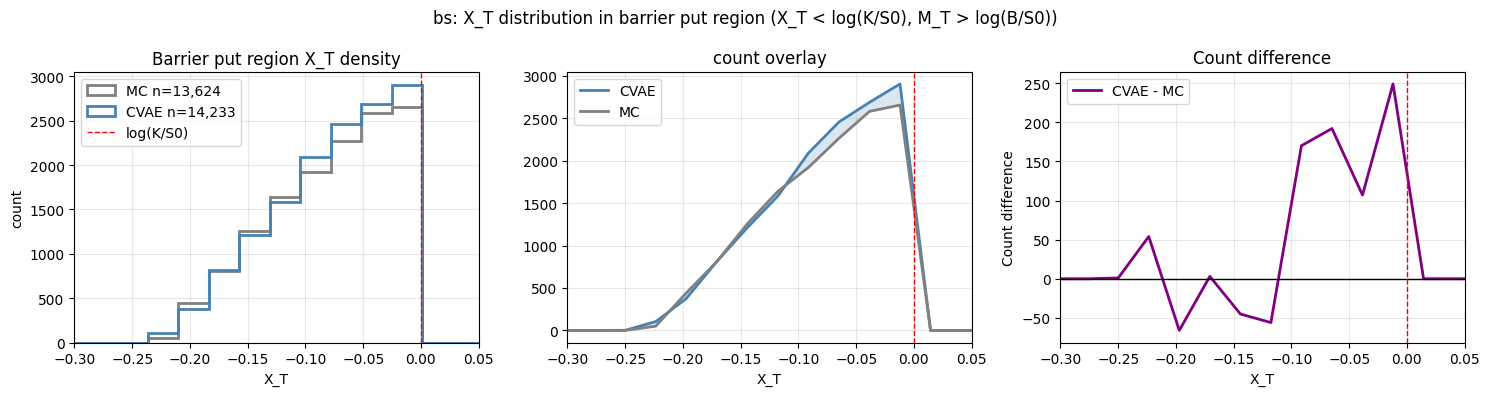

Barrier put threshold: X_T < 0.000000, M_T > -0.223144
MC   count/ratio: 13,624 / 100,000 = 13.6240%
CVAE count/ratio: 14,233 / 100,000 = 14.2330%
MC   X_T mean/std in BP region: -0.077720 / 0.053262
CVAE X_T mean/std in BP region: -0.075942 / 0.052956


In [184]:
# Barrier put region only: compare X_T distribution, no M_T axis
required_vars = ["mc_xt", "mc_mt", "cvae_xt", "cvae_mt"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise NameError(f"Run cell 16 first. Missing variables: {missing_vars}")

bp_bins = 100

k_log = np.log(K / S0)
b_log = np.log(B / S0)

# Barrier put payoff region: put ITM and alive above barrier.
mc_bp_mask = (mc_xt < k_log) & (mc_mt > b_log)
cvae_bp_mask = (cvae_xt < k_log) & (cvae_mt > b_log)

mc_bp_xt = np.asarray(mc_xt[mc_bp_mask], dtype=np.float64)
cvae_bp_xt = np.asarray(cvae_xt[cvae_bp_mask], dtype=np.float64)

if len(mc_bp_xt) == 0 or len(cvae_bp_xt) == 0:
    raise ValueError(
        f"No barrier-put samples to compare: MC={len(mc_bp_xt)}, CVAE={len(cvae_bp_xt)}"
    )

x_bp_all = np.concatenate([mc_bp_xt, cvae_bp_xt])
x_lo = np.min(x_all)
x_hi = np.max(x_all)

if not np.isfinite(x_lo) or not np.isfinite(x_hi) or x_lo == x_hi:
    x_lo, x_hi = float(np.min(x_bp_all)), float(np.max(x_bp_all))
    if x_lo == x_hi:
        x_lo -= 1e-6
        x_hi += 1e-6

x_edges = np.linspace(x_lo, x_hi, bp_bins + 1)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

mc_density, _ = np.histogram(mc_bp_xt, bins=x_edges, density=False)
cvae_density, _ = np.histogram(cvae_bp_xt, bins=x_edges, density=False)
density_diff = cvae_density - mc_density

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
axes[0].set_xlim(-0.3, 0.05)
axes[0].hist(
    mc_bp_xt,
    bins=x_edges,
    density=False,
    histtype="step",
    linewidth=2,
    color="grey",
    label=f"MC n={len(mc_bp_xt):,}",
)
axes[0].hist(
    cvae_bp_xt,
    bins=x_edges,
    density=False,
    histtype="step",
    linewidth=2,
    color="steelblue",
    label=f"CVAE n={len(cvae_bp_xt):,}",
)
axes[0].axvline(k_log, color="red", linestyle="--", linewidth=1.0, label="log(K/S0)")
axes[0].set_title("Barrier put region X_T density")
axes[0].set_xlabel("X_T")
axes[0].set_ylabel("count")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(x_centers, cvae_density, color="steelblue", linewidth=2, label="CVAE")
axes[1].plot(x_centers, mc_density, color="grey", linewidth=2, label="MC")
axes[1].fill_between(x_centers, mc_density, cvae_density, color="steelblue", alpha=0.2)
axes[1].axvline(k_log, color="red", linestyle="--", linewidth=1.0)
axes[1].set_title("count overlay")
axes[1].set_xlabel("X_T")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(x_centers, density_diff, color="purple", linewidth=2, label="CVAE - MC")
axes[2].axhline(0.0, color="black", linewidth=1.0)
axes[2].axvline(k_log, color="red", linestyle="--", linewidth=1.0)
axes[2].set_title("Count difference")
axes[2].set_xlabel("X_T")
axes[2].set_ylabel("Count difference")
axes[2].grid(alpha=0.3)
axes[2].legend()

fig.suptitle(
    f"{model_type}: X_T distribution in barrier put region "
    f"(X_T < log(K/S0), M_T > log(B/S0))"
)
plt.tight_layout()
plt.show()


print(f"Barrier put threshold: X_T < {k_log:.6f}, M_T > {b_log:.6f}")
print(f"MC   count/ratio: {len(mc_bp_xt):,} / {len(mc_xt):,} = {len(mc_bp_xt) / len(mc_xt):.4%}")
print(f"CVAE count/ratio: {len(cvae_bp_xt):,} / {len(cvae_xt):,} = {len(cvae_bp_xt) / len(cvae_xt):.4%}")
print(f"MC   X_T mean/std in BP region: {mc_bp_xt.mean():.6f} / {mc_bp_xt.std():.6f}")
print(f"CVAE X_T mean/std in BP region: {cvae_bp_xt.mean():.6f} / {cvae_bp_xt.std():.6f}")


# check eta distribution

In [ ]:
from e_0_generate import *
# eta min_max
if model_type == 'hes':
    prefix = 'heston'
else:
    prefix = model_type

result = compare_eta_minmax_all_vs_used_parallel( # 4m
    eta_path=eta_path,
    chunk_dir=chunk_dir,
    prefix=prefix,
    chunk_idxs=range(100),
    row_batch_size=100*(2**10),
    max_workers=8,
)

done: bs_chunk_007.h5 | unique idx in batches sum=65,536
done: bs_chunk_004.h5 | unique idx in batches sum=65,536
done: bs_chunk_005.h5 | unique idx in batches sum=65,536
done: bs_chunk_003.h5 | unique idx in batches sum=65,536
done: bs_chunk_001.h5 | unique idx in batches sum=65,536
done: bs_chunk_002.h5 | unique idx in batches sum=65,536
done: bs_chunk_000.h5 | unique idx in batches sum=65,536
done: bs_chunk_006.h5 | unique idx in batches sum=65,536
done: bs_chunk_008.h5 | unique idx in batches sum=65,536
done: bs_chunk_010.h5 | unique idx in batches sum=65,536
done: bs_chunk_015.h5 | unique idx in batches sum=65,536
done: bs_chunk_013.h5 | unique idx in batches sum=65,536
done: bs_chunk_009.h5 | unique idx in batches sum=65,536
done: bs_chunk_011.h5 | unique idx in batches sum=65,536
done: bs_chunk_012.h5 | unique idx in batches sum=65,536
done: bs_chunk_014.h5 | unique idx in batches sum=65,536
done: bs_chunk_018.h5 | unique idx in batches sum=65,536
done: bs_chunk_016.h5 | unique 

reading: bs_chunk_000.h5
reading: bs_chunk_001.h5
reading: bs_chunk_002.h5
reading: bs_chunk_003.h5
reading: bs_chunk_004.h5
reading: bs_chunk_005.h5
reading: bs_chunk_006.h5
reading: bs_chunk_007.h5
reading: bs_chunk_008.h5
reading: bs_chunk_009.h5
reading: bs_chunk_010.h5
reading: bs_chunk_011.h5
reading: bs_chunk_012.h5
reading: bs_chunk_013.h5
reading: bs_chunk_014.h5
reading: bs_chunk_015.h5
reading: bs_chunk_016.h5
reading: bs_chunk_017.h5
reading: bs_chunk_018.h5
reading: bs_chunk_019.h5
reading: bs_chunk_020.h5
reading: bs_chunk_021.h5
reading: bs_chunk_022.h5
reading: bs_chunk_023.h5
reading: bs_chunk_024.h5
reading: bs_chunk_025.h5
reading: bs_chunk_026.h5
reading: bs_chunk_027.h5
reading: bs_chunk_028.h5
reading: bs_chunk_029.h5
reading: bs_chunk_030.h5
reading: bs_chunk_031.h5
reading: bs_chunk_032.h5
reading: bs_chunk_033.h5
reading: bs_chunk_034.h5
reading: bs_chunk_035.h5
reading: bs_chunk_036.h5
reading: bs_chunk_037.h5
reading: bs_chunk_038.h5
reading: bs_chunk_039.h5


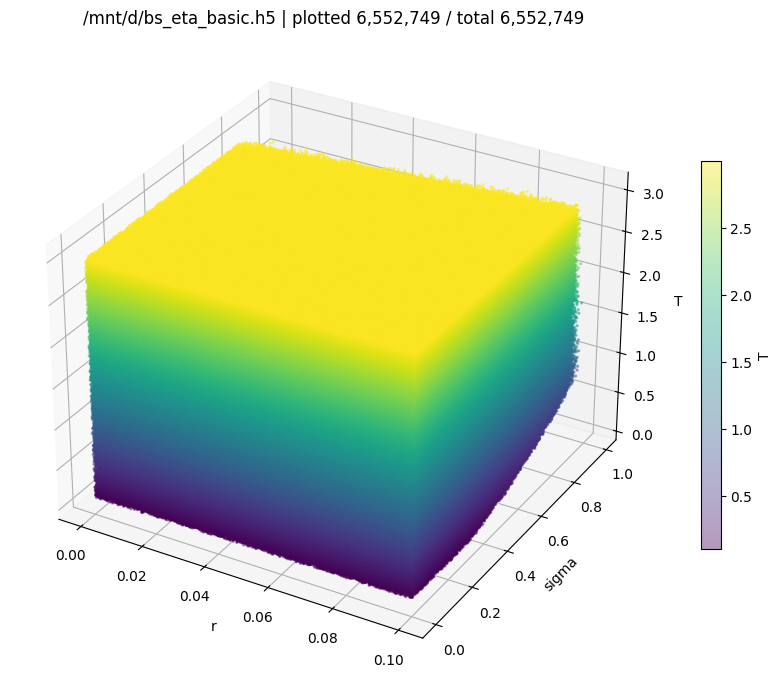

(array([       0,        2,        3, ..., 10776443, 10776444, 10776452],
       shape=(6552749,)),
 array([[0.01915195, 0.2364171 , 1.20417231],
        [0.04377277, 0.27285786, 2.86827853],
        [0.07853586, 0.73582226, 0.98725591],
        ...,
        [0.01301919, 0.36285841, 1.61197575],
        [0.09523179, 0.14520463, 1.33895806],
        [0.09136396, 0.22809733, 0.32350732]], shape=(6552749, 3)))

In [ ]:
# eta distribution
eta_idx = collect_eta_indices_from_chunks(
    chunk_dir=chunk_dir, eta_path=eta_path
)

eta_idx = np.asarray(eta_idx, dtype=np.int64)

with h5py.File("/mnt/d/bs_eta_basic.h5", "r") as h5:
    etas = h5["etas"][np.sort(eta_idx)]

In [ ]:
plot_eta_3d_density_scatter(etas, 
                            max_plot_points=200_000, 
                            bins=40,
                            elev=90,
                            azim=2,
                            )

NameError: name 'plot_eta_3d_density_scatter' is not defined

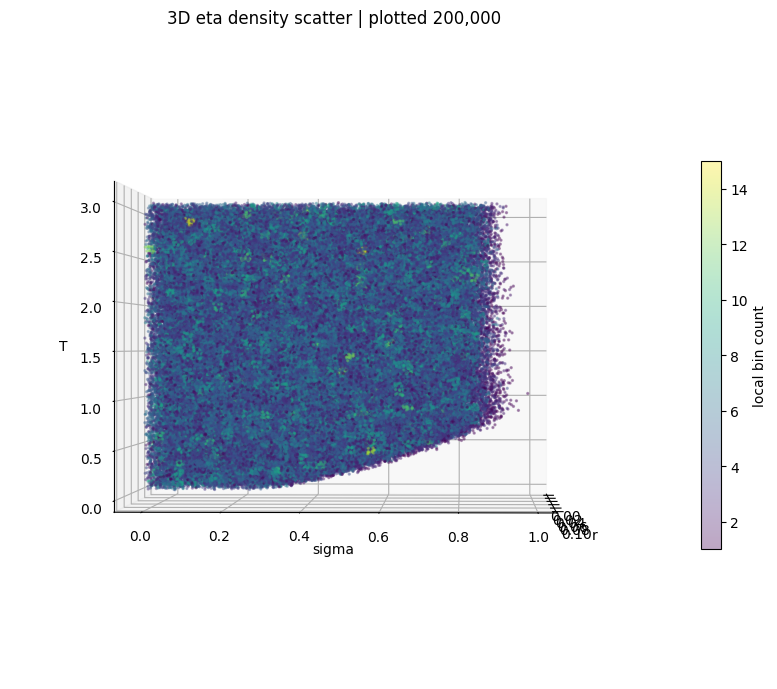

(array([[0.01923302, 0.03761809, 2.26668072],
        [0.0215819 , 0.28683947, 0.48302337],
        [0.08090458, 0.58038402, 1.77076816],
        ...,
        [0.02007971, 0.57556082, 2.45883169],
        [0.05025487, 0.1454769 , 1.7955309 ],
        [0.01083857, 0.41216508, 0.49160411]], shape=(200000, 3)),
 array([5., 6., 4., ..., 3., 6., 5.], shape=(200000,)))

In [74]:
plot_eta_3d_density_scatter(etas, 
                            max_plot_points=200_000, 
                            bins=40,
                            elev=0,
                            azim=2,
                            )

# robust checking

In [ ]:
# new robust value
from pathlib import Path
from f_robust import (
    ROBUSTNESS_VARIABLES_MAIN,
    build_sampling_summary,
    plot_sampling_comparison,
    run_robustness,
    save_robustness_results,
)

robust_config = {
    "models": (model_type,),
    "barrier": B,
    "barr_types": ("van", "barr"),
    "option_types": ("call", "put"),
    "run_fdm": True,
    "run_mc": True,
    "n_samples_list": (1_000, 10_000, 100_000),
    "mc_repeats": 50,
    "mc_dt": 0.001,
    "cvae": cvae,
    "checkpoint": ckpt,
    "device": device,
    "cvae_repeats": 50,
    "validate_samples": validate_samples,
    "valid_resample": valid_resample,
    "mt_corr": mt_corr,
}

robust_results = run_robustness( # bs : 7m, hes : 
    BS_eta,
    Hes_eta,
    ROBUSTNESS_VARIABLES_MAIN,
    **robust_config,
)

robust_stem = f"{Path(save_path).stem}_robustness"
pickle_path, csv_path = save_robustness_results(
    robust_results,
    output_dir="result/robust",
    stem=robust_stem,
)
print("raw results  :", pickle_path)
print("summary      :", csv_path)

[001] bs | r=0.0025 | van call
[002] bs | r=0.0025 | van put
[003] bs | r=0.0025 | barr call
[004] bs | r=0.0025 | barr put
[005] bs | r=0.0975 | van call
[006] bs | r=0.0975 | van put
[007] bs | r=0.0975 | barr call
[008] bs | r=0.0975 | barr put
[009] bs | sigma=0.05 | van call
[010] bs | sigma=0.05 | van put
[011] bs | sigma=0.05 | barr call
[012] bs | sigma=0.05 | barr put
[013] bs | sigma=0.75 | van call
[014] bs | sigma=0.75 | van put
[015] bs | sigma=0.75 | barr call
[016] bs | sigma=0.75 | barr put
[017] bs | T=0.15 | van call
[018] bs | T=0.15 | van put
[019] bs | T=0.15 | barr call
[020] bs | T=0.15 | barr put
[021] bs | T=2.85 | van call
[022] bs | T=2.85 | van put
[023] bs | T=2.85 | barr call
[024] bs | T=2.85 | barr put
raw results  : result/robust/cvae_bs_normal_weight_2_1024_16384_None_11-2e-05_12-2e-06_1_barrier_put_0.45_[15, 24, 78]_chunk1358_fine_robustness2.pkl
summary      : result/robust/cvae_bs_normal_weight_2_1024_16384_None_11-2e-05_12-2e-06_1_barrier_put_0.45_

In [14]:
# change model
# robust 값만 같다면 cvae값만 업데이트
from pathlib import Path
from f_robust import (
    ROBUSTNESS_VARIABLES_MAIN,
    build_sampling_summary,
    plot_sampling_comparison,
    run_robustness,
    save_robustness_results,
)

if model_type == 'bs' or model_type == 'bs_clip':
    if ROBUSTNESS_VARIABLES_MAIN['bs']['sigma'][1] == 0.8:
        old_robust_path = Path("result/robust/cvae_bs_2_128_4096_None_0.0001_1_[15, 24, 78]_chunk1261_robustness.pkl")
    elif ROBUSTNESS_VARIABLES_MAIN['bs']['sigma'][1] == 0.75:
        old_robust_path = Path("result/robust/cvae_bs_normal_weight_2_1024_16384_None_11-2e-05_12-2e-06_1_barrier_put_0.45_[15, 24, 78]_chunk1358_fine_robustness2.pkl")
else:
    old_robust_path = Path("result/robust/cvae_hes_2_128_4096_None_0.0001_1_[15, 24, 78]_chunk776_robustness.pkl")
old_results = pd.read_pickle(old_robust_path).copy()
old_results["model"] = model_type

new_cvae_results = run_robustness(
    BS_eta,
    Hes_eta,
    ROBUSTNESS_VARIABLES_MAIN,
    models=(model_type,),
    barrier=B,
    barr_types=("van", "barr"),
    option_types=("call", "put"),
    run_fdm=False,
    run_mc=False,
    n_samples_list=(1_000, 10_000, 100_000),
    mc_repeats=50,
    mc_dt=0.001,
    cvae=cvae,
    checkpoint=ckpt,
    device=device,
    cvae_repeats=50,
    validate_samples=validate_samples,
    valid_resample=valid_resample,
    mt_corr=mt_corr,
)

key_cols = ["model", "variable", "value", "barr_type", "option_type"]

cvae_cols = [
    "cvae",
    "cvae_std",
    "cvae_seconds",
    "cvae_results",
    "cvae_seconds_by_n",
    "sampling_diagnostics_by_n",
    "used_sample_count",
    "discarded_sample_pct",
    "regenerated_sample_pct",
    "mt_corrected_sample_pct",
    "cvae_abs_error",
    "cvae_rel_error_pct",
]

new_results = old_results.drop(
    columns=[col for col in cvae_cols if col in old_results.columns],
    errors="ignore",
).merge(
    new_cvae_results[key_cols + cvae_cols],
    on=key_cols,
    how="left",
)
if ROBUSTNESS_VARIABLES_MAIN['bs']['sigma'][1] == 0.8:
    robust_stem = f"{Path(save_path).stem}_robustness"
elif ROBUSTNESS_VARIABLES_MAIN['bs']['sigma'][1] == 0.75:
    robust_stem = f"{Path(save_path).stem}_robustness2"


pickle_path, csv_path = save_robustness_results(
    new_results,
    output_dir="result/robust",
    stem=robust_stem,
)

print("raw results:", pickle_path)
print("summary    :", csv_path)

[barrier samples] n=1,000 | validation=False | resample=False | mt_corr=True | used=1,000.0 | discarded=not checked | regenerated=0.0000% | mt_corrected=1.9880%
[barrier samples] n=10,000 | validation=False | resample=False | mt_corr=True | used=10,000.0 | discarded=not checked | regenerated=0.0000% | mt_corrected=1.9694%
[barrier samples] n=100,000 | validation=False | resample=False | mt_corr=True | used=100,000.0 | discarded=not checked | regenerated=0.0000% | mt_corrected=1.9781%
[001] hes | r=0.0025 | van call
[002] hes | r=0.0025 | van put
[003] hes | r=0.0025 | barr call
[004] hes | r=0.0025 | barr put
[barrier samples] n=1,000 | validation=False | resample=False | mt_corr=True | used=1,000.0 | discarded=not checked | regenerated=0.0000% | mt_corrected=2.6120%
[barrier samples] n=10,000 | validation=False | resample=False | mt_corr=True | used=10,000.0 | discarded=not checked | regenerated=0.0000% | mt_corrected=2.5944%
[barrier samples] n=100,000 | validation=False | resample=F


hes | r=0.0025


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
0,van,call,1000,0.101699,0.101504,0.005288,0.191800,0.102319,0.004931,0.609752
1,van,call,10000,0.101699,0.101265,0.001436,0.427210,0.101567,0.001368,0.129726
2,van,call,100000,0.101699,0.101535,0.000422,0.161276,0.101485,0.000462,0.210712
3,van,put,1000,0.097956,0.096966,0.004430,1.011125,0.098412,0.005304,0.465060
4,van,put,10000,0.097956,0.098251,0.001801,0.300598,0.098963,0.001496,1.028396
5,van,put,100000,0.097956,0.097814,0.000462,0.145415,0.098940,0.000364,1.004840
6,barr,call,1000,0.094438,0.094304,0.005255,0.141712,0.095439,0.004796,1.060428
7,barr,call,10000,0.094438,0.094084,0.001416,0.374948,0.094802,0.001493,0.385274
8,barr,call,100000,0.094438,0.094286,0.000422,0.161028,0.094696,0.000485,0.273475
9,barr,put,1000,0.006606,0.006605,0.000758,0.014195,0.006856,0.000875,3.779612


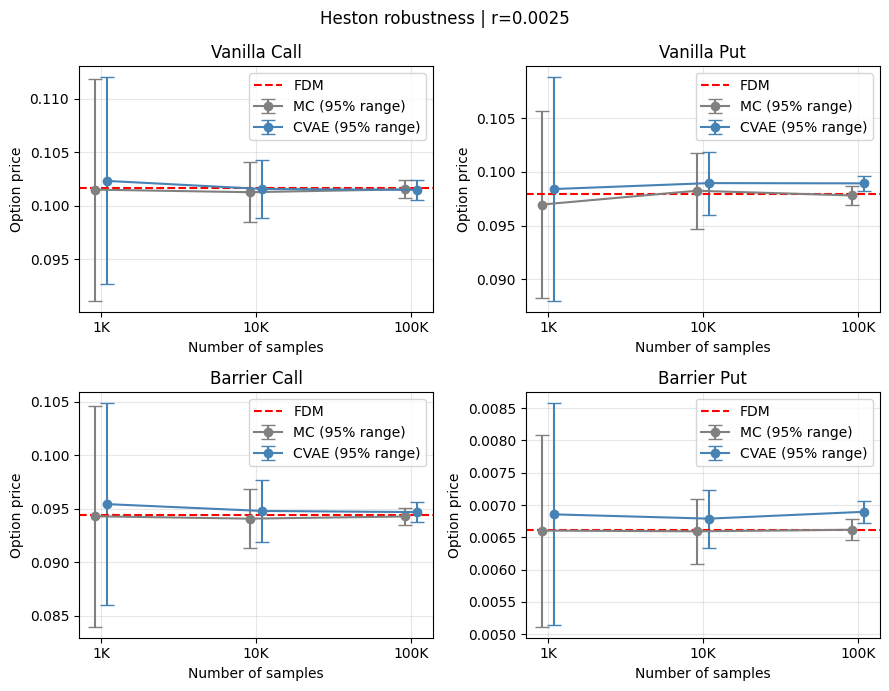


hes | r=0.0975


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
12,van,call,1000,0.185402,0.186063,0.004681,0.356768,0.184723,0.006248,0.366000
13,van,call,10000,0.185402,0.184885,0.001822,0.278672,0.184935,0.001669,0.251803
14,van,call,100000,0.185402,0.185349,0.000624,0.028291,0.184797,0.000685,0.326354
15,van,put,1000,0.049344,0.048960,0.002710,0.776870,0.049916,0.003164,1.160007
16,van,put,10000,0.049344,0.049350,0.001127,0.013773,0.049634,0.000783,0.588134
17,van,put,100000,0.049344,0.049226,0.000412,0.239190,0.049713,0.000405,0.749265
18,barr,call,1000,0.172891,0.173537,0.004880,0.373593,0.172664,0.006641,0.131268
19,barr,call,10000,0.172891,0.172325,0.001915,0.327803,0.173253,0.001635,0.209312
20,barr,call,100000,0.172891,0.172881,0.000637,0.005644,0.173072,0.000698,0.104306
21,barr,put,1000,0.002832,0.002818,0.000418,0.479516,0.003115,0.000474,10.014267


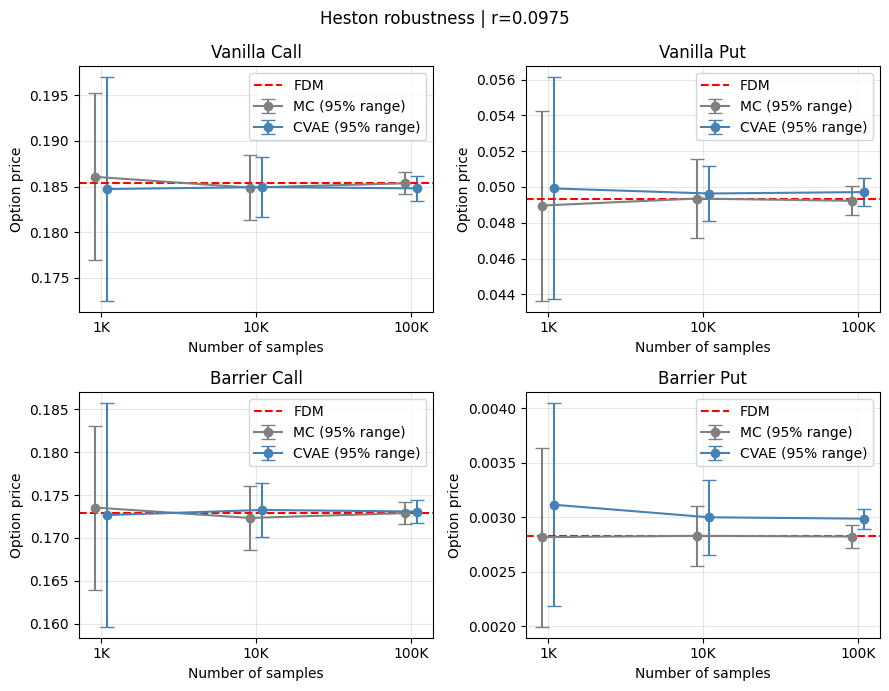


hes | kappa=1.3


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
24,van,call,1000,0.122137,0.120785,0.004684,1.106843,0.121706,0.004709,0.352998
25,van,call,10000,0.122137,0.121397,0.001448,0.605747,0.121756,0.001205,0.312046
26,van,call,100000,0.122137,0.121480,0.000444,0.537634,0.121600,0.000373,0.439802
27,van,put,1000,0.078134,0.078797,0.003702,0.847519,0.078726,0.004683,0.757855
28,van,put,10000,0.078134,0.077412,0.001308,0.924456,0.078639,0.001453,0.645876
29,van,put,100000,0.078134,0.077657,0.000522,0.610879,0.078725,0.000381,0.755523
30,barr,call,1000,0.112502,0.111533,0.005146,0.861445,0.112661,0.004943,0.141019
31,barr,call,10000,0.112502,0.111827,0.001464,0.599688,0.112698,0.001367,0.173933
32,barr,call,100000,0.112502,0.111926,0.000451,0.512279,0.112652,0.000390,0.133103
33,barr,put,1000,0.004834,0.004727,0.000657,2.209612,0.005066,0.000613,4.804329


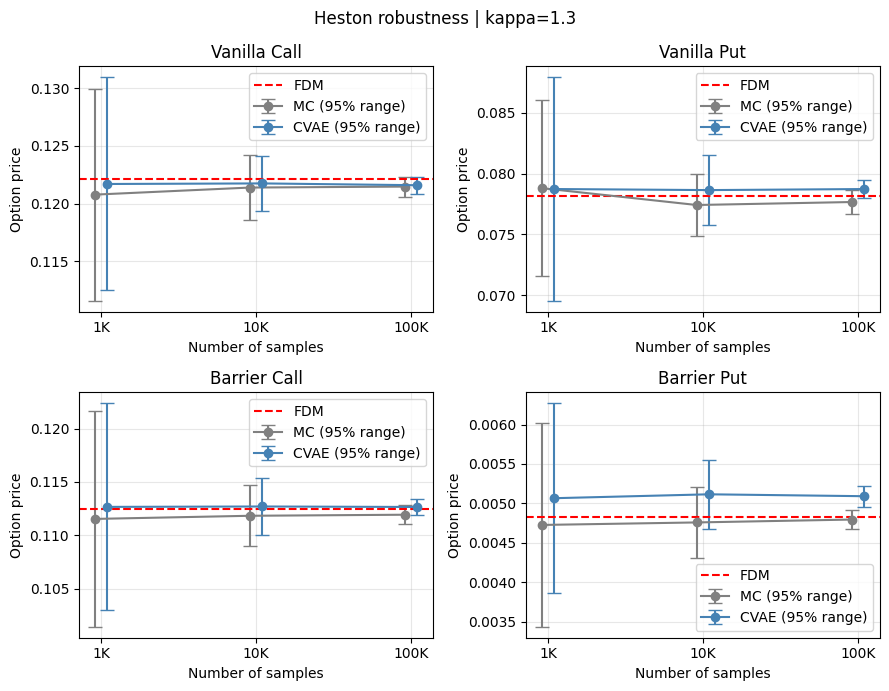


hes | kappa=4.5


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
36,van,call,1000,0.128112,0.128970,0.006329,0.669480,0.127641,0.005645,0.367231
37,van,call,10000,0.128112,0.128151,0.001761,0.030758,0.127966,0.001728,0.113830
38,van,call,100000,0.128112,0.128092,0.000594,0.015216,0.127772,0.000623,0.265040
39,van,put,1000,0.084109,0.083187,0.005008,1.096355,0.084834,0.004179,0.860932
40,van,put,10000,0.084109,0.083986,0.001071,0.146886,0.084231,0.001414,0.145059
41,van,put,100000,0.084109,0.084259,0.000403,0.178001,0.084527,0.000427,0.496764
42,barr,call,1000,0.120618,0.121060,0.006078,0.366837,0.120497,0.005738,0.099957
43,barr,call,10000,0.120618,0.120734,0.001730,0.096845,0.120842,0.001703,0.186178
44,barr,call,100000,0.120618,0.120607,0.000591,0.008847,0.120640,0.000628,0.018540
45,barr,put,1000,0.005936,0.005909,0.000858,0.465315,0.006428,0.000750,8.273513


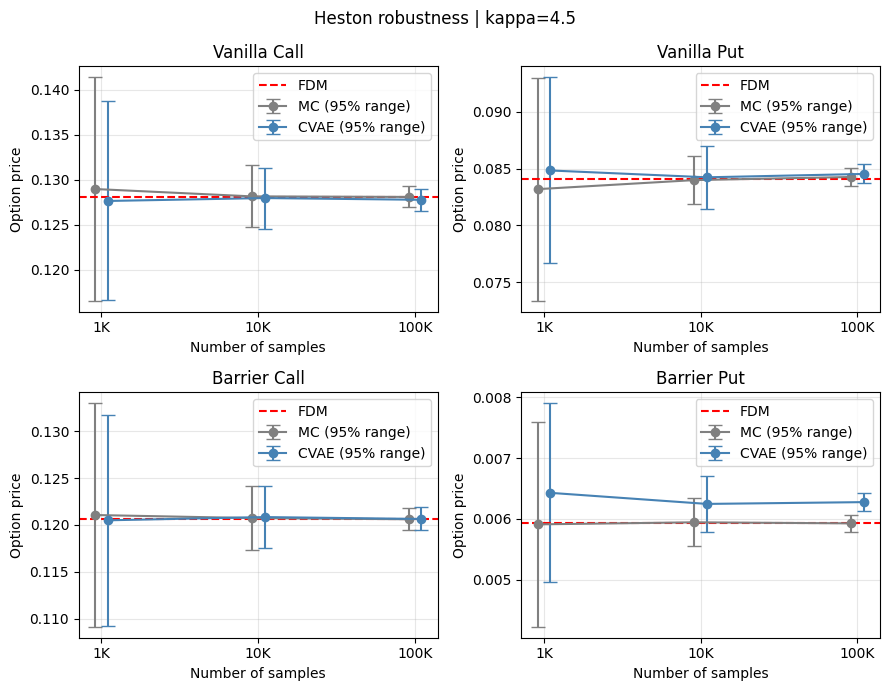


hes | theta=0.035


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
48,van,call,1000,0.113521,0.113285,0.004025,0.207140,0.113591,0.004061,0.062171
49,van,call,10000,0.113521,0.113086,0.001120,0.382640,0.113392,0.001367,0.113721
50,van,call,100000,0.113521,0.113118,0.000418,0.354254,0.113384,0.000463,0.120769
51,van,put,1000,0.069518,0.069031,0.004307,0.700183,0.068973,0.004009,0.784683
52,van,put,10000,0.069518,0.069178,0.001184,0.489287,0.070502,0.001239,1.415091
53,van,put,100000,0.069518,0.069003,0.000399,0.741545,0.070084,0.000471,0.813924
54,barr,call,1000,0.107461,0.107337,0.003554,0.115374,0.108239,0.004096,0.723648
55,barr,call,10000,0.107461,0.107092,0.001103,0.342871,0.107883,0.001352,0.393259
56,barr,call,100000,0.107461,0.107101,0.000431,0.335351,0.107807,0.000440,0.322253
57,barr,put,1000,0.005679,0.005680,0.000640,0.015208,0.005911,0.000727,4.084385


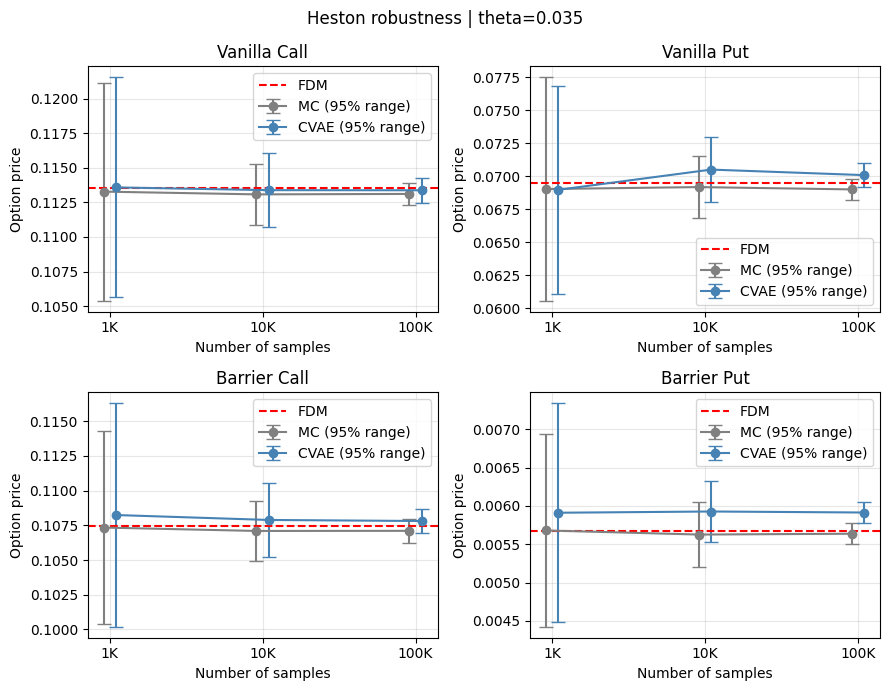


hes | theta=0.15


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
60,van,call,1000,0.180117,0.180280,0.007685,0.090183,0.180865,0.007391,0.415341
61,van,call,10000,0.180117,0.179802,0.002807,0.174956,0.179413,0.002544,0.391011
62,van,call,100000,0.180117,0.180195,0.000703,0.042890,0.179873,0.000815,0.135529
63,van,put,1000,0.136115,0.136993,0.006921,0.645193,0.137086,0.005442,0.713300
64,van,put,10000,0.136115,0.136233,0.002124,0.086593,0.136726,0.001849,0.449257
65,van,put,100000,0.136115,0.136086,0.000673,0.021465,0.136459,0.000606,0.252618
66,barr,call,1000,0.147779,0.147695,0.007226,0.057364,0.149941,0.007240,1.462598
67,barr,call,10000,0.147779,0.147478,0.002630,0.203994,0.148271,0.002624,0.332817
68,barr,call,100000,0.147779,0.147821,0.000717,0.028164,0.148827,0.000724,0.708748
69,barr,put,1000,0.002629,0.002678,0.000508,1.861844,0.002892,0.000635,9.982726


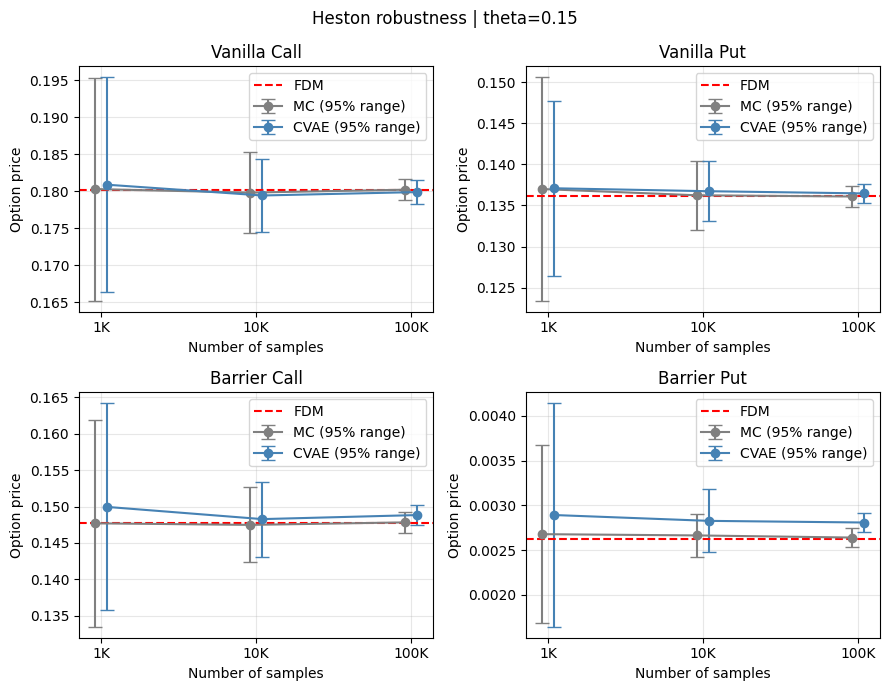


hes | xi=0.15


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
72,van,call,1000,0.129477,0.129755,0.005001,0.215165,0.129132,0.004585,0.266016
73,van,call,10000,0.129477,0.129768,0.001787,0.224932,0.128854,0.001851,0.480667
74,van,call,100000,0.129477,0.129377,0.000580,0.076566,0.129153,0.000565,0.249766
75,van,put,1000,0.085474,0.084884,0.004677,0.690282,0.085025,0.004078,0.525874
76,van,put,10000,0.085474,0.085439,0.001124,0.040843,0.085688,0.001353,0.250766
77,van,put,100000,0.085474,0.085599,0.000314,0.146370,0.085554,0.000438,0.093163
78,barr,call,1000,0.122153,0.122413,0.004874,0.212244,0.122459,0.004574,0.250460
79,barr,call,10000,0.122153,0.122451,0.001729,0.243518,0.122003,0.001787,0.123288
80,barr,call,100000,0.122153,0.122091,0.000579,0.051313,0.122249,0.000544,0.078060
81,barr,put,1000,0.007581,0.007459,0.000892,1.602090,0.007993,0.000771,5.435838


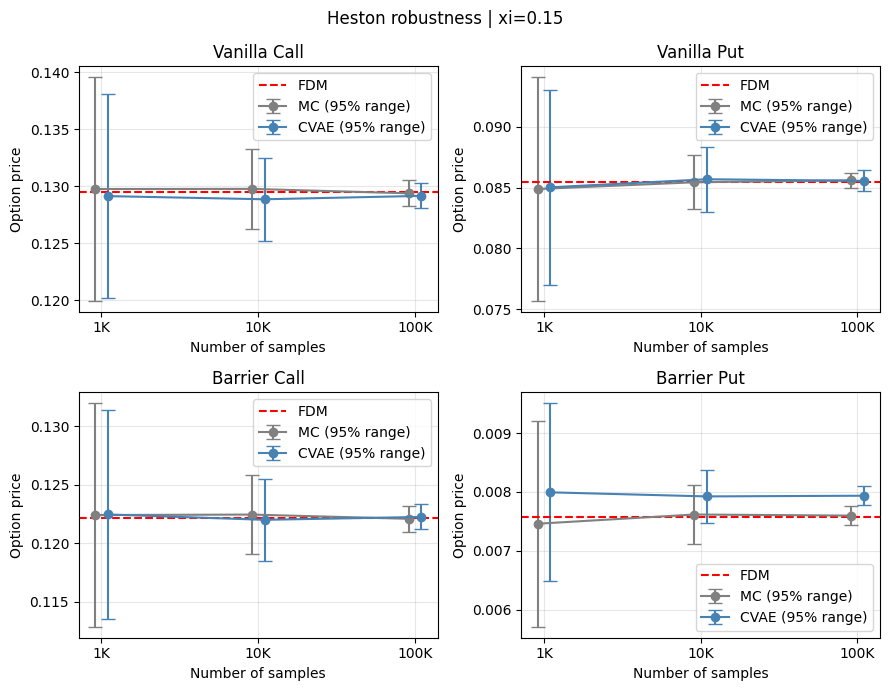


hes | xi=0.6


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
84,van,call,1000,0.122957,0.122463,0.004459,0.402243,0.122263,0.004134,0.564291
85,van,call,10000,0.122957,0.122370,0.001387,0.477446,0.122764,0.001550,0.157319
86,van,call,100000,0.122957,0.122359,0.000481,0.486559,0.122418,0.000390,0.438438
87,van,put,1000,0.078955,0.078416,0.004021,0.682627,0.079874,0.004539,1.164486
88,van,put,10000,0.078955,0.078397,0.001327,0.705811,0.079699,0.001500,0.942109
89,van,put,100000,0.078955,0.078361,0.000515,0.752022,0.079437,0.000447,0.610429
90,barr,call,1000,0.113859,0.113674,0.004319,0.162096,0.113890,0.004181,0.027641
91,barr,call,10000,0.113859,0.113384,0.001479,0.417517,0.114397,0.001513,0.472762
92,barr,call,100000,0.113859,0.113369,0.000474,0.429963,0.114023,0.000409,0.143850
93,barr,put,1000,0.004814,0.004696,0.000719,2.440744,0.005149,0.000694,6.954125


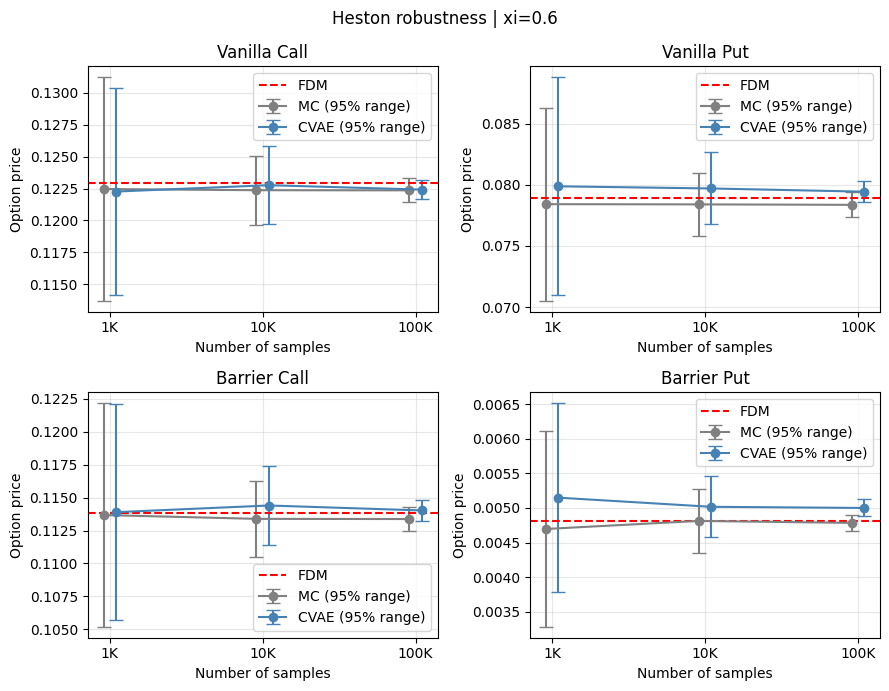


hes | rho=-0.95


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
96,van,call,1000,0.123538,0.122511,0.004121,0.831312,0.123497,0.003953,0.032762
97,van,call,10000,0.123538,0.123268,0.001401,0.218240,0.123481,0.001382,0.046212
98,van,call,100000,0.123538,0.123427,0.000387,0.089522,0.123267,0.000358,0.218992
99,van,put,1000,0.079535,0.079733,0.004845,0.248967,0.079007,0.004602,0.663780
100,van,put,10000,0.079535,0.079757,0.001371,0.278781,0.080387,0.001403,1.071401
101,van,put,100000,0.079535,0.079478,0.000438,0.071321,0.080323,0.000371,0.990299
102,barr,call,1000,0.115593,0.114700,0.004285,0.773284,0.116091,0.003997,0.430428
103,barr,call,10000,0.115593,0.115305,0.001467,0.249937,0.116116,0.001375,0.452188
104,barr,call,100000,0.115593,0.115506,0.000406,0.075960,0.115846,0.000397,0.218810
105,barr,put,1000,0.003724,0.003811,0.000531,2.344063,0.003875,0.000692,4.070429


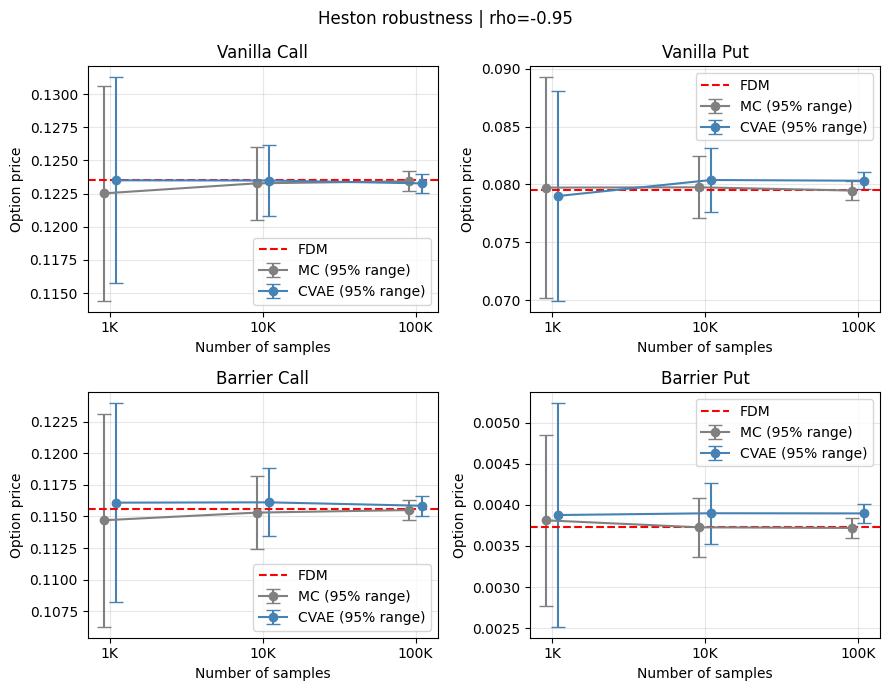


hes | rho=-0.05


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
108,van,call,1000,0.125276,0.125448,0.006525,0.137157,0.125639,0.007211,0.289296
109,van,call,10000,0.125276,0.125289,0.001713,0.009950,0.124729,0.001863,0.436759
110,van,call,100000,0.125276,0.125089,0.000586,0.149612,0.125031,0.000660,0.196146
111,van,put,1000,0.081274,0.080611,0.004351,0.815150,0.081464,0.003737,0.234360
112,van,put,10000,0.081274,0.080886,0.001180,0.476902,0.081973,0.001362,0.859835
113,van,put,100000,0.081274,0.081201,0.000420,0.089151,0.081747,0.000448,0.581739
114,barr,call,1000,0.116908,0.116883,0.006162,0.021799,0.117554,0.006939,0.552772
115,barr,call,10000,0.116908,0.116868,0.001693,0.033921,0.116922,0.001794,0.011581
116,barr,call,100000,0.116908,0.116713,0.000583,0.167087,0.117213,0.000653,0.260439
117,barr,put,1000,0.011123,0.011333,0.001072,1.885542,0.011415,0.000888,2.621367


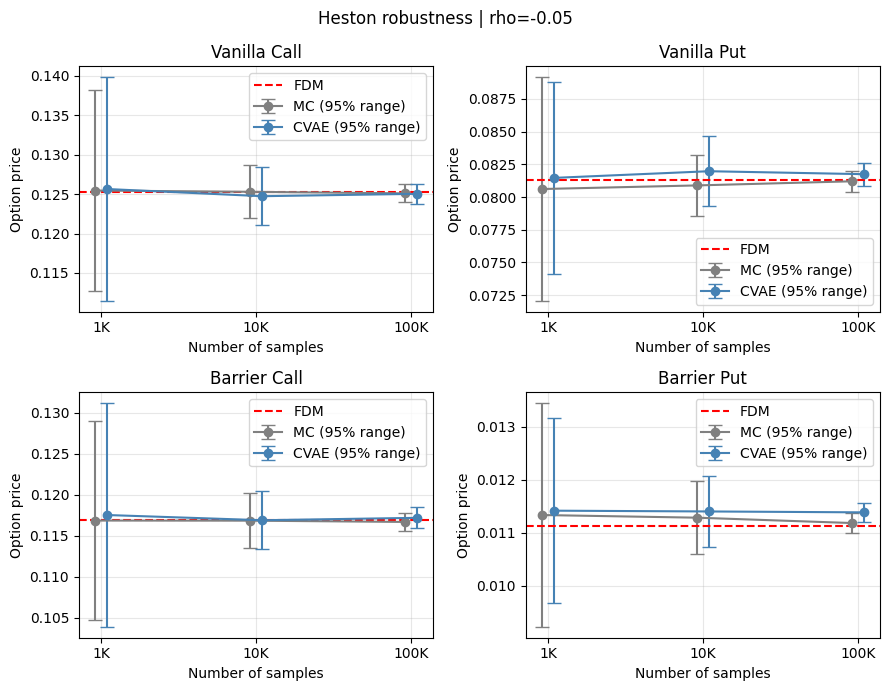


hes | Y0=0.005


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
120,van,call,1000,0.109671,0.108843,0.003762,0.754255,0.110365,0.004016,0.633010
121,van,call,10000,0.109671,0.109389,0.001558,0.256918,0.109554,0.001256,0.106402
122,van,call,100000,0.109671,0.109492,0.000396,0.163033,0.109577,0.000411,0.085239
123,van,put,1000,0.065668,0.065651,0.004194,0.025724,0.066080,0.004263,0.626882
124,van,put,10000,0.065668,0.065655,0.001292,0.019746,0.066140,0.001053,0.719191
125,van,put,100000,0.065668,0.065414,0.000366,0.387385,0.066229,0.000360,0.854007
126,barr,call,1000,0.105022,0.104105,0.003592,0.873436,0.106155,0.004033,1.079160
127,barr,call,10000,0.105022,0.104784,0.001502,0.226840,0.105235,0.001300,0.203077
128,barr,call,100000,0.105022,0.104897,0.000401,0.119280,0.105292,0.000429,0.257554
129,barr,put,1000,0.006958,0.007109,0.000842,2.166565,0.006996,0.000823,0.537281


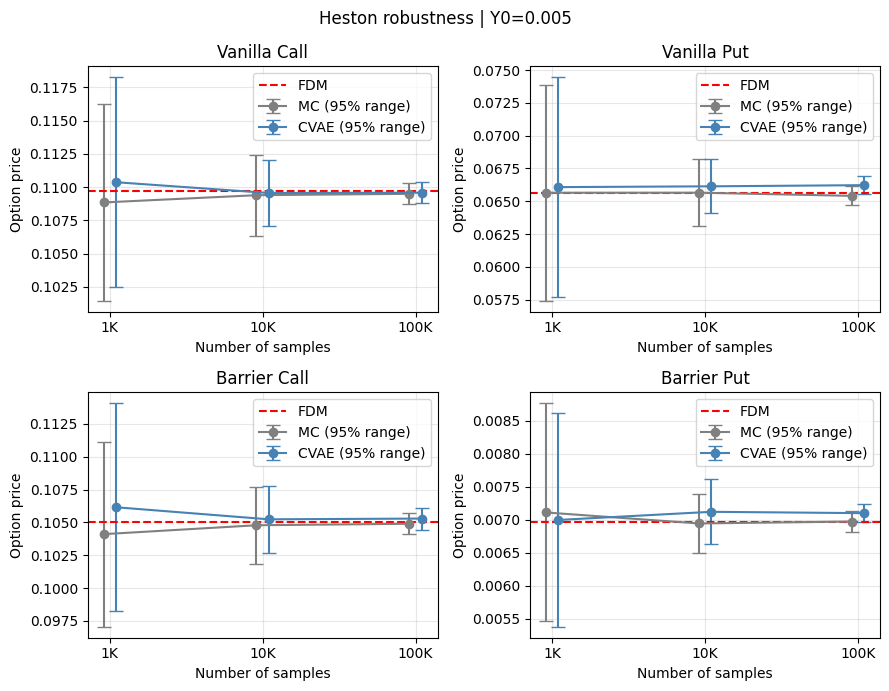


hes | Y0=0.15


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
132,van,call,1000,0.152118,0.154289,0.005623,1.427089,0.151430,0.005585,0.451802
133,van,call,10000,0.152118,0.151944,0.002313,0.114146,0.152721,0.002012,0.396887
134,van,call,100000,0.152118,0.152110,0.000778,0.005235,0.152863,0.000623,0.489853
135,van,put,1000,0.108115,0.107161,0.004609,0.882181,0.108898,0.006558,0.724109
136,van,put,10000,0.108115,0.108160,0.001864,0.040994,0.109355,0.001522,1.146978
137,van,put,100000,0.108115,0.108101,0.000469,0.012867,0.109192,0.000507,0.996105
138,barr,call,1000,0.132511,0.134404,0.005387,1.428782,0.132557,0.005543,0.035011
139,barr,call,10000,0.132511,0.132409,0.002302,0.076592,0.133915,0.002071,1.059886
140,barr,call,100000,0.132511,0.132563,0.000800,0.039913,0.134051,0.000602,1.162691
141,barr,put,1000,0.002977,0.002994,0.000460,0.566836,0.003225,0.000535,8.319345


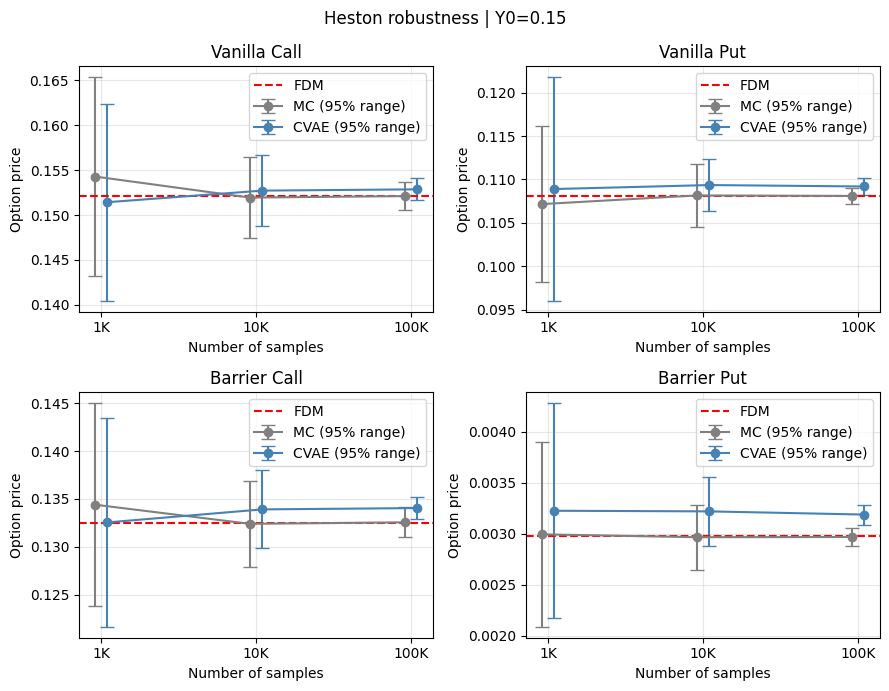


hes | T=0.15


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
144,van,call,1000,0.035931,0.035266,0.001312,1.849514,0.035278,0.001203,1.817585
145,van,call,10000,0.035931,0.035914,0.000517,0.047386,0.035292,0.000444,1.778429
146,van,call,100000,0.035931,0.035975,0.000129,0.123776,0.035349,0.000127,1.619016
147,van,put,1000,0.031441,0.031961,0.001539,1.652700,0.031962,0.001707,1.656728
148,van,put,10000,0.031441,0.031639,0.000425,0.630910,0.031679,0.000589,0.758715
149,van,put,100000,0.031441,0.031521,0.000177,0.253527,0.031741,0.000162,0.953565
150,barr,call,1000,0.035929,0.035265,0.001312,1.848941,0.035277,0.001203,1.814196
151,barr,call,10000,0.035929,0.035913,0.000517,0.044977,0.035289,0.000444,1.780526
152,barr,call,100000,0.035929,0.035974,0.000130,0.124510,0.035347,0.000128,1.618954
153,barr,put,1000,0.024102,0.024633,0.001357,2.202787,0.024665,0.001366,2.334548


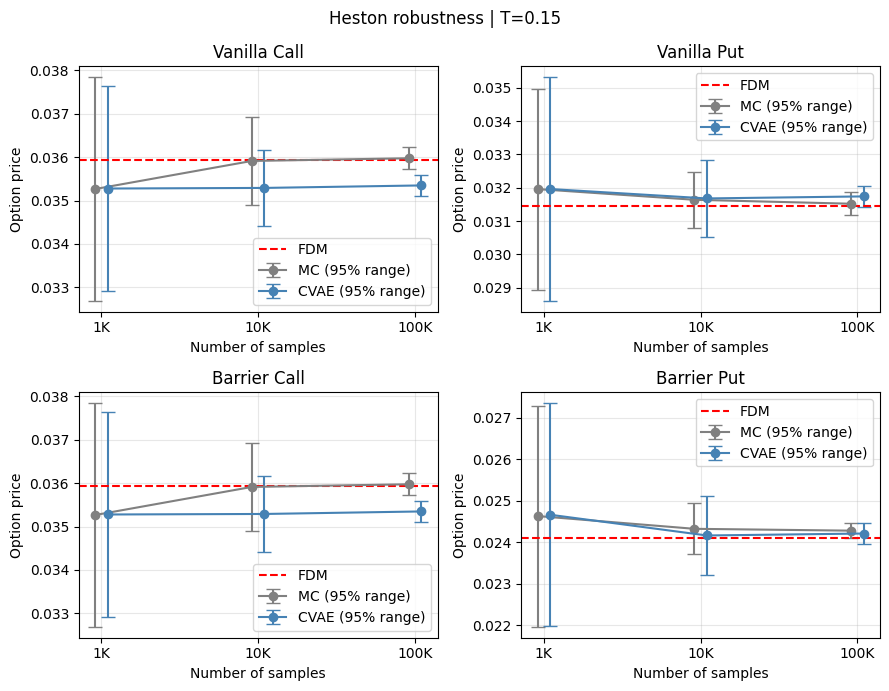


hes | T=2.85


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
156,van,call,1000,0.182909,0.183805,0.006910,0.489335,0.181439,0.006839,0.803695
157,van,call,10000,0.182909,0.182868,0.002518,0.022647,0.182647,0.002083,0.143267
158,van,call,100000,0.182909,0.182643,0.000739,0.145830,0.182630,0.000774,0.152884
159,van,put,1000,0.100963,0.100353,0.004526,0.603625,0.100958,0.004824,0.004858
160,van,put,10000,0.100963,0.100810,0.001569,0.151529,0.101951,0.001570,0.979194
161,van,put,100000,0.100963,0.100703,0.000519,0.257203,0.101741,0.000547,0.770751
162,barr,call,1000,0.156854,0.157888,0.006980,0.659345,0.156588,0.007644,0.169268
163,barr,call,10000,0.156854,0.156878,0.002446,0.015703,0.158458,0.002419,1.022902
164,barr,call,100000,0.156854,0.156687,0.000730,0.106246,0.158099,0.000755,0.794008
165,barr,put,1000,0.002196,0.002234,0.000399,1.711694,0.002424,0.000389,10.361780


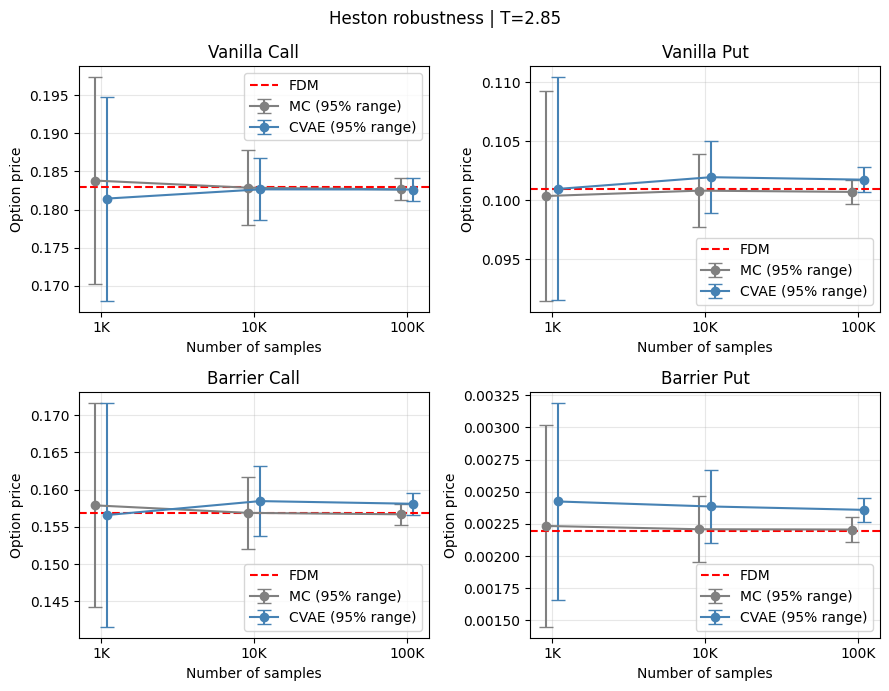

In [15]:
from pathlib import Path
import pandas as pd
from f_robust import (
    ROBUSTNESS_VARIABLES_MAIN,
    build_sampling_summary,
    plot_sampling_comparison,
    run_robustness,
    save_robustness_results,
)
from f_robust import (
    ROBUSTNESS_VARIABLES_MAIN,
    build_sampling_summary,
    plot_sampling_comparison,
    run_robustness,
    save_robustness_results,
)

if ROBUSTNESS_VARIABLES_MAIN['bs']['sigma'][1] == 0.8:
    robust_stem = f"{Path(save_path).stem}_robustness"
elif ROBUSTNESS_VARIABLES_MAIN['bs']['sigma'][1] == 0.75:
    robust_stem = f"{Path(save_path).stem}_robustness2"
pkl_path = Path("result/robust") / f"{robust_stem}.pkl"
robust_results = pd.read_pickle(pkl_path)

if "model" in robust_results.columns and model_type not in set(robust_results["model"].astype(str)):
    if model_type in {"bs_clip", "hes_clip"}:
        robust_results = robust_results.copy()
        robust_results["model"] = model_type

sampling_summary = build_sampling_summary(robust_results)

for variable, values in ROBUSTNESS_VARIABLES_MAIN[model_type].items():
    for value in values:
        print(f"\n{model_type} | {variable}={value:g}")
        case_summary = sampling_summary[
            sampling_summary["model"].eq(model_type)
            & sampling_summary["variable"].eq(variable)
            & np.isclose(sampling_summary["value"], value)
        ]
        display(case_summary[[
            "barr_type",
            "option_type",
            "n_samples",
            "reference",
            "mc_mean",
            "mc_std",
            "mc_rel_error_pct",
            "cvae_mean",
            "cvae_std",
            "cvae_rel_error_pct",
        ]])

        plot_sampling_comparison(
            robust_results,
            model_type,
            variable,
            value,
        )

failed_cases = robust_results[robust_results["error"].notna()]
if not failed_cases.empty:
    print("\n계산 실패 항목")
    display(failed_cases[[
        "model", "variable", "value", "barr_type", "option_type", "error"
    ]])